In [1]:
import pandas as pd
from pathlib import Path

In [2]:
LME = Path.cwd() / "data" / "lme_aluminium.csv"
MWP_M = Path.cwd() / "data" / "midwest_premium.csv"
US_IMPORTS = Path.cwd() / "data" / "us_imports_by_country.csv"
MWP_FUTURES= Path.cwd() / "data" / "midwest_premium_curve.csv"
DUP = Path.cwd() / "data" / "europe_duty_unpaid_premium.csv"
DP = Path.cwd() / "data" / "europe_duty_paid_premium.csv"
CANADA_EXPORTS = Path.cwd() / "data" / "canada_exports_by_country.csv"

In [3]:
lme = pd.read_csv(LME)
mwp_m = pd.read_csv(MWP_M)
mwp_futures = pd.read_csv(MWP_FUTURES)
dp = pd.read_csv(DP)

lme['date'] = pd.to_datetime(lme['date'])
mwp_m['date'] = pd.to_datetime(mwp_m['date'])
mwp_futures['date'] = pd.to_datetime(mwp_futures['date'])
dp['date'] = pd.to_datetime(dp['date'])

In [4]:
lme.columns

Index(['date', 'cash', 'three_month', 'stock'], dtype='object')

In [5]:
# Look at the landed cost (LME + DP + freight + tariff) vs. MW physical (LME + MWP)
# Before and after tariffs in june 4 2025

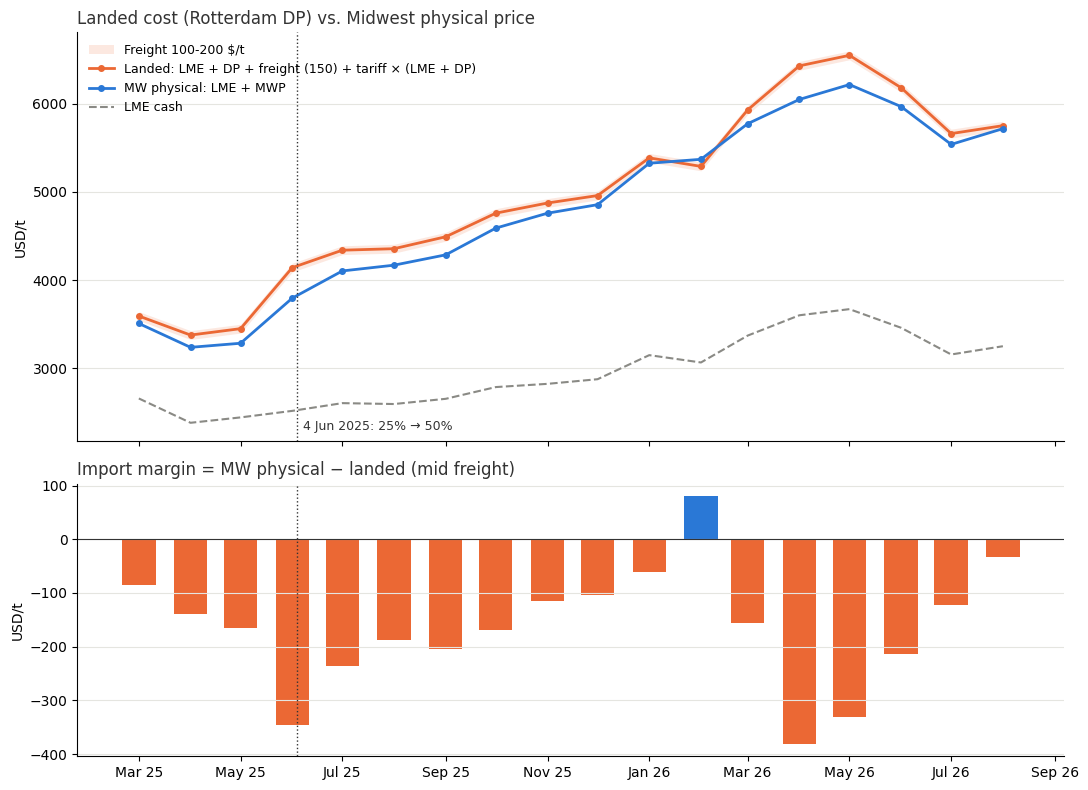

,before (Apr-May 25),after (Jul 25 on),change
mw_physical,3260.0,5194.0,1934.0
landed,3413.0,5354.0,1941.0
gap,-152.0,-160.0,-8.0
mwp,848.0,2119.0,1271.0
tariff,653.0,1735.0,1082.0


In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Freight Rotterdam -> Midwest (USD/t): assumption, no free series. Mid + low/high band.
FREIGHT_LOW, FREIGHT_MID, FREIGHT_HIGH = 100, 150, 200
TARIFF_DATE = pd.Timestamp("2025-06-04")

# Monthly averages (month start index)
lme_m = lme.set_index("date")["cash"].resample("MS").mean().rename("lme")
dp_m = dp.set_index("date")["premium_usd_t"].rename("dp")
mwp_hist = mwp_m.set_index("date")["premium_usd_t"]
# Extend MWP past USGS coverage with the M01 futures settle at month-end
m01 = (mwp_futures[mwp_futures["tenor"] == 1].set_index("date")["premium_usd_t"]
       .resample("MS").last())
mwp_all = mwp_hist.combine_first(m01).rename("mwp")

df = pd.concat([lme_m, dp_m, mwp_all], axis=1).dropna()

# Section 232 rate by origin: (effective date, rate). Canada was exempt from 20 May 2019 until exemptions ended
# on 12 Mar 2025; other origins paid 10% until then. The 16 Aug-15 Sep 2020 reimposition on Canada is left out
# (it hit only part of Canadian unwrought metal and predates the price data used here).
TARIFF_STEPS = {
    "Canada": [("2019-05-20", 0.00), ("2025-03-12", 0.25), ("2025-06-04", 0.50)],
    "Other":  [("2018-03-23", 0.10), ("2025-03-12", 0.25), ("2025-06-04", 0.50)],
}

def tariff_rate(month_start, origin="Other"):
    """Day-weighted average rate over the month, so Mar 2025 and Jun 2025 blend the two regimes."""
    days = pd.date_range(month_start, month_start + pd.offsets.MonthEnd(0), freq="D")
    steps = pd.Series({pd.Timestamp(d): r for d, r in TARIFF_STEPS[origin]})
    return steps.reindex(steps.index.union(days)).ffill().loc[days].mean()

df["tariff_rate"] = [tariff_rate(d) for d in df.index]
df["fob"] = df["lme"] + df["dp"]
df["tariff"] = df["tariff_rate"] * df["fob"]
df["landed"] = df["fob"] + FREIGHT_MID + df["tariff"]
df["landed_low"] = df["fob"] + FREIGHT_LOW + df["tariff"]
df["landed_high"] = df["fob"] + FREIGHT_HIGH + df["tariff"]
df["mw_physical"] = df["lme"] + df["mwp"]
df["gap"] = df["mw_physical"] - df["landed"]   # >0: importing pays; <0: tariff not fully passed through

# The 25% rate only applied to all origins from 12 Mar 2025, so start the window there
plot = df.loc["2025-03-01":]

BLUE, ORANGE, INK, MUTED = "#2a78d6", "#eb6834", "#333333", "#8a8a85"
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})

ax1.fill_between(plot.index, plot["landed_low"], plot["landed_high"], color=ORANGE, alpha=0.15, lw=0,
                 label=f"Freight {FREIGHT_LOW}-{FREIGHT_HIGH} $/t")
ax1.plot(plot.index, plot["landed"], color=ORANGE, lw=2, marker="o", ms=4,
         label=f"Landed: LME + DP + freight ({FREIGHT_MID}) + tariff × (LME + DP)")
ax1.plot(plot.index, plot["mw_physical"], color=BLUE, lw=2, marker="o", ms=4,
         label="MW physical: LME + MWP")
ax1.plot(plot.index, plot["lme"], color=MUTED, lw=1.5, ls="--", label="LME cash")
ax1.set_ylabel("USD/t")
ax1.set_title("Landed cost (Rotterdam DP) vs. Midwest physical price", loc="left", color=INK)
ax1.legend(loc="upper left", frameon=False, fontsize=9)

gap_colors = [BLUE if g >= 0 else ORANGE for g in plot["gap"]]
ax2.bar(plot.index, plot["gap"], width=20, color=gap_colors)
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("USD/t")
ax2.set_title("Import margin = MW physical − landed (mid freight)", loc="left", color=INK)

for ax in (ax1, ax2):
    ax.axvline(TARIFF_DATE, color=INK, lw=1, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.spines[["top", "right"]].set_visible(False)
ax1.annotate("4 Jun 2025: 25% → 50%", xy=(TARIFF_DATE, ax1.get_ylim()[0]), xytext=(4, 8),
             textcoords="offset points", fontsize=9, color=INK)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Average levels before / after the 4 Jun step (full months only)
pre, post = df.loc["2025-04-01":"2025-05-01"], df.loc["2025-07-01":]
summary = pd.DataFrame({"before (Apr-May 25)": pre[["mw_physical", "landed", "gap", "mwp", "tariff"]].mean(),
                        "after (Jul 25 on)": post[["mw_physical", "landed", "gap", "mwp", "tariff"]].mean()}).round(0)
summary["change"] = summary.iloc[:, 1] - summary.iloc[:, 0]
summary

takeaway: physical and landed price rose together, respectively by 1934\$ and 1941\$, indicating full passthrough of tariff costs. However, the import margin is still negative. One thing to note is that the import margin has a magnitude of 100-200 for most months, which is the same magnitude as the freight cost assumption, so changes in the freight cost can significantly alter the margins.

note: MWP after june 2026 is the front-month futures settle at month-end (since USGS monthly series stops at june 2026)

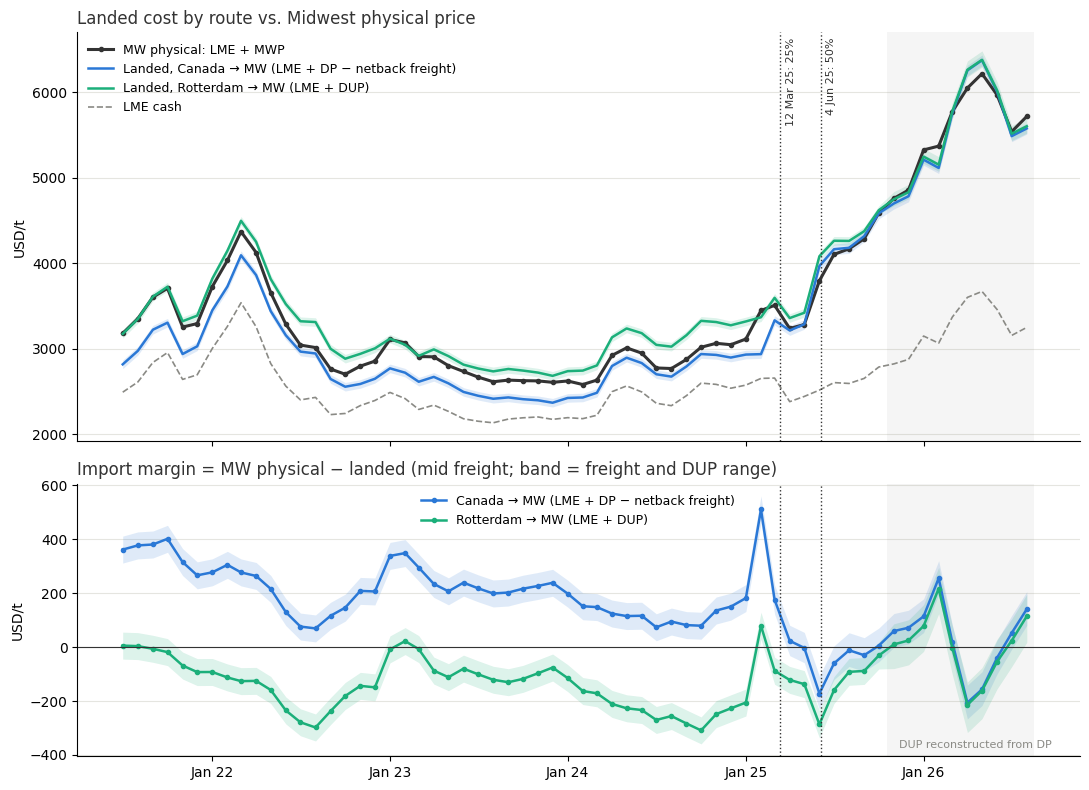

,Nov 24–Jan 25 (pre),Apr–May 25 (25%),Jul 25 on (50%)
mw_physical,3075.0,3260.0,5194.0
mwp,509.0,848.0,2119.0
landed_ca,2919.0,3250.0,5179.0
gap_ca,156.0,10.0,15.0
landed_rtm,3302.0,3390.0,5218.0
gap_rtm,-227.0,-130.0,-24.0


,step 1: 12 Mar 25 (25%),step 2: 4 Jun 25 (50%)
Canada,0.56,1.00
Rotterdam,2.10,1.06


In [7]:
# Landed cost by route, each with its own opportunity premium (see README, Method):
#   Rotterdam -> MW: FOB = LME + DUP. In-bond metal is re-exported uncleared, so the EU 3% duty is never paid.
#   Canada -> MW:    FOB = LME + DP - freight(Canada -> Rotterdam). Canadian metal enters the EU duty-free (CETA),
#                    so its alternative is the duty-paid price, netted back to Canada.
# Freight (USD/t) is an assumption, no free series: (low, mid, high)
FREIGHT = {
    "rtm_mw": (100, 150, 200),   # Rotterdam -> Midwest: transatlantic + inland
    "ca_rtm": (30, 50, 80),      # Canada -> Rotterdam: transatlantic, netback leg
    "ca_mw":  (30, 50, 80),      # Canada -> Midwest: rail / truck
}
dup_r = pd.read_csv(Path.cwd() / "data" / "europe_duty_unpaid_premium_reconstructed.csv", parse_dates=["date"]).set_index("date")

r = pd.concat([lme_m, dp_m, mwp_all,
               dup_r["premium_usd_t"].rename("dup"),
               dup_r[["dup_low", "dup_high"]].min(axis=1).rename("dup_lo"),
               dup_r[["dup_low", "dup_high"]].max(axis=1).rename("dup_hi"),
               dup_r["source"]], axis=1).dropna(subset=["lme", "dp", "mwp", "dup"])
r.loc[r["source"] == "observed", ["dup_lo", "dup_hi"]] = r["dup"]   # band only where DUP is reconstructed
r["mw_physical"] = r["lme"] + r["mwp"]
r["t_ca"] = [tariff_rate(d, "Canada") for d in r.index]
r["t_ot"] = [tariff_rate(d, "Other") for d in r.index]

def landed_rtm(dup, f):
    fob = r["lme"] + dup
    return fob + f + r["t_ot"] * fob

def landed_ca(f_netback, f_mw):
    fob = r["lme"] + r["dp"] - f_netback
    return fob + f_mw + r["t_ca"] * fob

lo, mid, hi = 0, 1, 2
r["landed_rtm"] = landed_rtm(r["dup"], FREIGHT["rtm_mw"][mid])
r["landed_ca"] = landed_ca(FREIGHT["ca_rtm"][mid], FREIGHT["ca_mw"][mid])
# Cheapest / dearest combinations of freight (and DUP band) for the shaded ranges
r["landed_rtm_lo"] = landed_rtm(r["dup_lo"], FREIGHT["rtm_mw"][lo])
r["landed_rtm_hi"] = landed_rtm(r["dup_hi"], FREIGHT["rtm_mw"][hi])
r["landed_ca_lo"] = landed_ca(FREIGHT["ca_rtm"][hi], FREIGHT["ca_mw"][lo])   # larger netback freight = cheaper FOB
r["landed_ca_hi"] = landed_ca(FREIGHT["ca_rtm"][lo], FREIGHT["ca_mw"][hi])
for route in ["rtm", "ca"]:
    r[f"gap_{route}"] = r["mw_physical"] - r[f"landed_{route}"]
    r[f"gap_{route}_lo"] = r["mw_physical"] - r[f"landed_{route}_hi"]
    r[f"gap_{route}_hi"] = r["mw_physical"] - r[f"landed_{route}_lo"]

STEP1 = pd.Timestamp("2025-03-12")
GREEN = "#1baf7a"
ROUTES = {"ca": ("Canada → MW (LME + DP − netback freight)", BLUE),
          "rtm": ("Rotterdam → MW (LME + DUP)", GREEN)}
recon = r.index[r["source"] == "reconstructed"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})
ax1.plot(r.index, r["mw_physical"], color=INK, lw=2.2, marker="o", ms=3, label="MW physical: LME + MWP")
for route, (label, color) in ROUTES.items():
    ax1.fill_between(r.index, r[f"landed_{route}_lo"], r[f"landed_{route}_hi"], color=color, alpha=0.15, lw=0)
    ax1.plot(r.index, r[f"landed_{route}"], color=color, lw=1.8, label=f"Landed, {label}")
    ax2.fill_between(r.index, r[f"gap_{route}_lo"], r[f"gap_{route}_hi"], color=color, alpha=0.15, lw=0)
    ax2.plot(r.index, r[f"gap_{route}"], color=color, lw=1.8, marker="o", ms=3, label=label)
if len(recon):
    for ax in (ax1, ax2):
        ax.axvspan(recon[0] - pd.Timedelta(days=15), recon[-1] + pd.Timedelta(days=15),
                   color=MUTED, alpha=0.08, lw=0)
    ax2.annotate("DUP reconstructed from DP", xy=(recon[0], ax2.get_ylim()[0]), xytext=(4, 6),
                 textcoords="offset points", fontsize=8, color=MUTED)
ax1.plot(r.index, r["lme"], color=MUTED, lw=1.2, ls="--", label="LME cash")
ax1.set_ylabel("USD/t")
ax1.set_title("Landed cost by route vs. Midwest physical price", loc="left", color=INK)
ax1.legend(loc="upper left", frameon=False, fontsize=9)
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("USD/t")
ax2.set_title("Import margin = MW physical − landed (mid freight; band = freight and DUP range)", loc="left", color=INK)
ax2.legend(loc="upper center", frameon=False, fontsize=9)
for ax in (ax1, ax2):
    for d in (STEP1, TARIFF_DATE):
        ax.axvline(d, color=INK, lw=1, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d, txt in [(STEP1, "12 Mar 25: 25%"), (TARIFF_DATE, "4 Jun 25: 50%")]:
    ax1.annotate(txt, xy=(d, ax1.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
                 fontsize=8, color=INK, rotation=90, va="top")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Averages by regime (full months only) and pass-through beta = ΔMW physical / Δlanded per route and step
REGIMES = {
    "Nov 24–Jan 25 (pre)": ("2024-11-01", "2025-01-01"),
    "Apr–May 25 (25%)":    ("2025-04-01", "2025-05-01"),
    "Jul 25 on (50%)":     ("2025-07-01", None),
}
cols = ["mw_physical", "mwp", "landed_ca", "gap_ca", "landed_rtm", "gap_rtm"]
by_regime = pd.DataFrame({k: r.loc[a:b, cols].mean() for k, (a, b) in REGIMES.items()}).round(0)
keys = list(REGIMES)
# Rotterdam already paid 10% before step 1, so its Δlanded at step 1 is small and its β is noisy
beta = pd.DataFrame({
    name: {"Canada": d["mw_physical"] / d["landed_ca"], "Rotterdam": d["mw_physical"] / d["landed_rtm"]}
    for name, d in [("step 1: 12 Mar 25 (25%)", by_regime[keys[1]] - by_regime[keys[0]]),
                    ("step 2: 4 Jun 25 (50%)", by_regime[keys[2]] - by_regime[keys[1]])]
}).round(2)
display(by_regime)
beta


The first version (cell 5) prices the landed cost off LME + DP for a single Rotterdam-style route. The route chart above splits the two routes and uses each one's actual opportunity premium (README, Method). The Rotterdam route uses DUP, because in-bond metal never pays the EU duty. That lowers its landed cost by about (DP − DUP) × (1 + t), ≈ 140 \$/t at 50%. The Canada route uses DP netted back by Canada → Rotterdam freight. Shaded months use DUP reconstructed from DP, and the band includes that reconstruction range.

Takeaway: once every origin pays the same rate, the premium sits at Canada parity. The Canada margin went from +156 \$/t (Nov 24–Jan 25) to +10 at 25% and +15 at 50%, inside the freight band, and the Rotterdam margin closed from −227 to −24. Step 2 passed through in full on both routes (β = 1.00 and 1.06). Step 1 looks incomplete on the Canada route (β = 0.56) only because Canada started below the price; the next cell shows why.


In [8]:
# Who sets the US price? Canada parity is the premium only while Canada is the marginal supplier: indifferent between
# the US and Europe, so it splits its exports between them. Before 12 Mar 2025 the tariff was two-tier (Canada 0%,
# others 10%). Two checks by regime:
#   MWP − Canada parity above zero even at the highest freight: the US pays Canada more than its European alternative,
#     a rent, so another origin's cost sets the price
#   US share of Canada's unwrought exports near 100%: a corner, not a split
# The two-tier window ends Jan 2025, before the 10 Feb 2025 announcement.
ca_x = pd.read_csv(CANADA_EXPORTS, parse_dates=["date"])
ca_x = ca_x[ca_x["hs"] == 7601].pivot_table(index="date", columns="country", values="tonnes", aggfunc="sum")
TIERS = {"Two-tier: Canada 0%, others 10% (Jul 21–Jan 25)": ("2021-07-01", "2025-01-01"),
         "Uniform 25% (Apr–May 25)": ("2025-04-01", "2025-05-01"),
         "Uniform 50%, before Hormuz (Jul 25–Feb 26)": ("2025-07-01", "2026-02-01")}

def who_sets(a, b):
    x = r.loc[a:b]
    return {"months": len(x),
            "MWP − Canada parity, mid freight": x["gap_ca"].mean(),
            "MWP − Canada parity, highest freight": x["gap_ca_lo"].mean(),
            "months above parity at the highest freight": int((x["gap_ca_lo"] > 0).sum()),
            "MWP − Rotterdam parity, mid freight": x["gap_rtm"].mean(),
            "US share of Canada's exports, %": ca_x.loc[a:b, "USA"].sum() / ca_x.loc[a:b, "World"].sum() * 100}

pd.DataFrame({k: who_sets(a, b) for k, (a, b) in TIERS.items()}).T.round(0)

,months,"MWP − Canada parity, mid freight","MWP − Canada parity, highest freight",months above parity at the highest freight,"MWP − Rotterdam parity, mid freight","US share of Canada's exports, %"
"Two-tier: Canada 0%, others 10% (Jul 21–Jan 25)",43.0,210.0,160.0,43.0,-143.0,94.0
Uniform 25% (Apr–May 25),2.0,10.0,-45.0,0.0,-130.0,89.0
"Uniform 50%, before Hormuz (Jul 25–Feb 26)",8.0,50.0,-10.0,3.0,-5.0,70.0


Takeaway:
- **Before Mar 2025, Canada was not the price-setter.** Under the two-tier tariff (Canada 0%, others 10%) the premium sat above Canada parity in all 43 months, by 210 \$/t on average and still by 160 \$/t at the highest freight. Canada shipped 94% of its exports to the US: a corner, not a split. The US paid Canada more than its European alternative, so Canada earned a rent and an origin paying 10% set the price. The premium sat between Canada parity and Rotterdam parity at 10% (143 \$/t below it), so that tonne was cheaper than European metal, which fits Europe shipping almost none.
- **The first 25% step made the tariff uniform, and the gap closed.** The premium sat 10 \$/t from Canada parity at 25% and 50 \$/t at 50%, both inside the freight band. Under 50% Canada split its exports (70% to the US), so it was indifferent between the two markets, which is what makes its parity bind.
- **So the parity model holds from 12 Mar 2025, not before.** The pre-2025 gap that looked like a freight error is Canada's rent under a tariff that favoured it. Freight may explain part of its size, but not a gap that stays positive at the highest freight in all 43 months.
- **It explains step 1's low β.** Canada's landed cost rose 331 \$/t, but it started 156 \$/t below the price, so the rent absorbed the first part of the step: 331 − 156 = 175, against an observed rise of 185 \$/t (cell 7). Pass-through was complete once Canada became the marginal supplier. The windows are two and three months, so read this as consistent, not as proof.
- **A Canada-only cut would undo it** (cell 22): it restores a two-tier tariff, so Canada would go back to earning a rent and parity at the lower rate stops being the price.

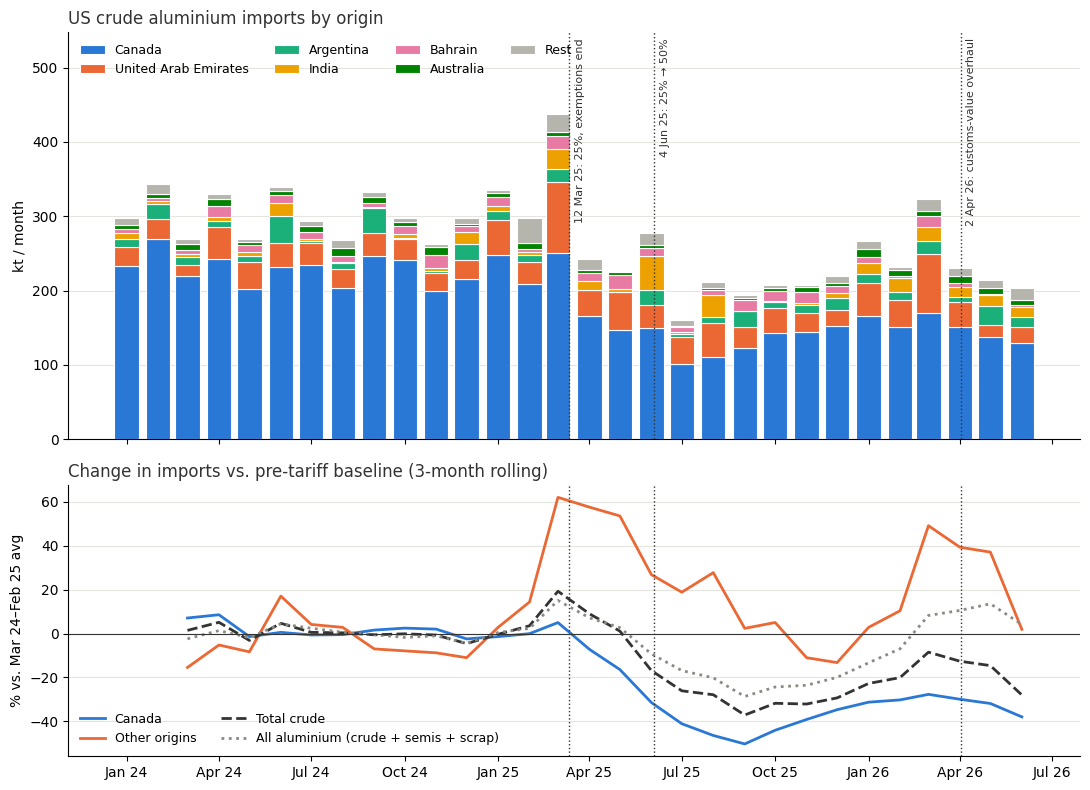

,Mar 24–Feb 25 (Canada 0%),Mar 25 (front-running),Apr–May 25 (25%),Jul 25–Mar 26 (50%),"Apr–Jun 26 (50%, new valuation)",50% vs. baseline (%)
country,,,,,,
Canada,224.5,250.0,156.5,140.2,139.3,-38.0
United Arab Emirates,30.5,95.6,43.0,38.8,23.9,27.0
Argentina,12.9,18.0,0.2,12.1,15.2,-6.0
India,6.1,27.4,8.1,10.8,13.9,77.0
Bahrain,9.8,17.5,14.7,9.8,3.1,0.0
Australia,7.0,5.4,3.9,5.6,7.9,-20.0
Rest,8.6,24.1,8.6,7.4,12.4,-14.0
Total crude,299.4,438.0,235.0,224.7,215.7,-25.0
All aluminium,463.9,619.0,405.0,401.4,483.0,-13.0


In [9]:
# US primary (crude, HTS 7601) imports by origin around the tariff steps
imports = pd.read_csv(US_IMPORTS, parse_dates=["date"])

EVENTS = {
    pd.Timestamp("2025-03-12"): "12 Mar 25: 25%, exemptions end",
    TARIFF_DATE:                "4 Jun 25: 25% → 50%",
    pd.Timestamp("2026-04-02"): "2 Apr 26: customs-value overhaul",
}

crude = (imports[imports["country"] != "Total"]
         .pivot_table(index="date", columns="country", values="crude_t", aggfunc="sum")
         .fillna(0))
total_crude = imports[imports["country"] == "Total"].set_index("date")["crude_t"]
total_all = imports[imports["country"] == "Total"].set_index("date")["total_t"]   # crude + semis + scrap

# Main origins: the largest crude suppliers since 2024; everything else folds into "Rest"
TOP_N = 5
top = (crude.loc["2024-01-01":].drop(columns="Other").sum()
       .sort_values(ascending=False).index[:TOP_N + 1].tolist())   # Canada + next 5
flows = crude[top].copy()
flows["Rest"] = total_crude - flows.sum(axis=1)   # residual so the stack equals the reported total
flows = flows.loc["2024-01-01":] / 1e3            # kt

SERIES_COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#b5b4ad"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})

bottom = pd.Series(0.0, index=flows.index)
for col, color in zip(flows.columns, SERIES_COLORS):
    ax1.bar(flows.index, flows[col], bottom=bottom, width=24, color=color,
            edgecolor="white", linewidth=0.8, label=col)
    bottom += flows[col]
ax1.set_ylabel("kt / month")
ax1.set_title("US crude aluminium imports by origin", loc="left", color=INK)
ax1.set_ylim(0, flows.sum(axis=1).max() * 1.25)
ax1.legend(loc="upper left", frameon=False, fontsize=9, ncol=4)

# Change vs. pre-tariff baseline (12 months to Feb 2025), 3-month rolling, by group
groups = pd.DataFrame({"Canada": flows["Canada"],
                       "Other origins": flows.drop(columns="Canada").sum(axis=1)})
groups["Total crude"] = groups.sum(axis=1)
groups["All aluminium (crude + semis + scrap)"] = total_all.loc["2024-01-01":] / 1e3
base_g = groups.loc["2024-03-01":"2025-02-01"].mean()
pct = (groups.rolling(3).mean() / base_g - 1) * 100
for col, color, ls in zip(pct.columns, [BLUE, ORANGE, INK, MUTED], ["-", "-", "--", ":"]):
    ax2.plot(pct.index, pct[col], color=color, lw=2, ls=ls, label=col)
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("% vs. Mar 24–Feb 25 avg")
ax2.set_title("Change in imports vs. pre-tariff baseline (3-month rolling)", loc="left", color=INK)
ax2.legend(loc="lower left", frameon=False, fontsize=9, ncol=2)

for ax in (ax1, ax2):
    for d in EVENTS:
        ax.axvline(d, color=INK, lw=1, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d, label in EVENTS.items():
    ax1.annotate(label, xy=(d, ax1.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
                 fontsize=8, color=INK, rotation=90, va="top")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Average monthly imports (kt) in each tariff regime, full months only
WINDOWS = {
    "Mar 24–Feb 25 (Canada 0%)":       ("2024-03-01", "2025-02-01"),
    "Mar 25 (front-running)":          ("2025-03-01", "2025-03-01"),
    "Apr–May 25 (25%)":                ("2025-04-01", "2025-05-01"),
    "Jul 25–Mar 26 (50%)":             ("2025-07-01", "2026-03-01"),
    "Apr–Jun 26 (50%, new valuation)": ("2026-04-01", "2026-06-01"),
}
table = flows.assign(**{"Total crude": flows.sum(axis=1),
                        "All aluminium": total_all.loc["2024-01-01":] / 1e3})
regimes = pd.DataFrame({k: table.loc[a:b].mean() for k, (a, b) in WINDOWS.items()}).round(1)
regimes.loc["Canada share (%)"] = (regimes.loc["Canada"] / regimes.loc["Total crude"] * 100).round(0)
regimes["50% vs. baseline (%)"] = ((regimes["Jul 25–Mar 26 (50%)"] / regimes["Mar 24–Feb 25 (Canada 0%)"] - 1) * 100).round(0)
regimes.loc["Canada share (%)", "50% vs. baseline (%)"] = None
regimes

Takeaway: Big rallies in imports prior to tariff changes. Canadian imports fell sharply after the two significant dates and has remained at about 62% of baseline level. UAE and India have come in to fill the gap, with Indian AL up 77% from baseline and UAE AL up 27%. Total crude imports still down and at around 80% of baseline level this year. 

**Note: the Hormuz shock (from 2 Mar 2026) is mixed into the 2026 numbers.** Iran declared the Strait of Hormuz closed to commercial traffic on 2 Mar 2026. Qatalum (50% Hydro) shut down on 3 Mar for lack of gas and has run at about 60% of capacity since 12 Mar. EGA's Al Taweelah smelter and Alba were hit by strikes, and Gulf metal (about 9% of world supply) could not leave the region. South32's Mozal smelter, which mostly supplies Europe, went into care and maintenance in the same period.

The timing points to the shock, not the tariff, as the main driver of what moved in 2026:
- **Rotterdam DP:** 361 \$/t in Feb 26, then 483 (Mar), 586 (Apr) and 596 (May), easing to 484 by Aug as a ceasefire partly reopened the strait. DUP moved the same way (270 → 482 → 385). The earlier rise from ~190 (Jul 25) to 361 (Feb 26) predates Hormuz.
- **US imports from the Gulf:** UAE + Bahrain + Oman + Qatar averaged 45 kt/month in Jul 25–Feb 26, spiked to 101 kt in March (metal shipped before the closure), then fell to 31 kt/month in Apr–Jun 26 (22 kt in May).
- **What it does not explain:** total crude imports in Apr–Jun 26 (216 kt/month) are about where they were in Jul 25–Feb 26 (212 kt/month). The fall against the pre-tariff baseline (299 kt) happened in 2025, so that part is still the tariff. Semis and scrap imports had started rising in Jan–Feb 26, before the closure.

Consequence: the "Apr–Jun 26" windows above mix the tariff with the Gulf shock, and the 2026 swings in the route margins (cell 7) come mostly from DP. Anything attributed to the tariff should use months up to Feb 2026. The forecast and hedge-ratio cells at the end split the 50% period at the closure. TODO: add a 2 Mar 2026 event line to the charts above.

Sources: [Qatalum update (SMM)](https://news.metal.com/newscontent/103806228-qatalum-shifts-from-full-shutdown-to-60-capacity-operational-update-amid-strait-of-hormuz-disruption), [CNBC, 30 Mar 2026](https://www.cnbc.com/2026/03/30/iran-attacks-aluminum-producers-shockwaves-market-metals.html), [Hydro Q2 2026](https://www.hydro.com/en/global/media/news/2026/hydros-second-quarter-2026-operational-strength-delivering-solid-results/), [Fastmarkets, 24 Aug 2026](https://www.fastmarkets.com/insights/european-aluminium-market-watchful-of-proposed-us-canada-tariff-reduction/).

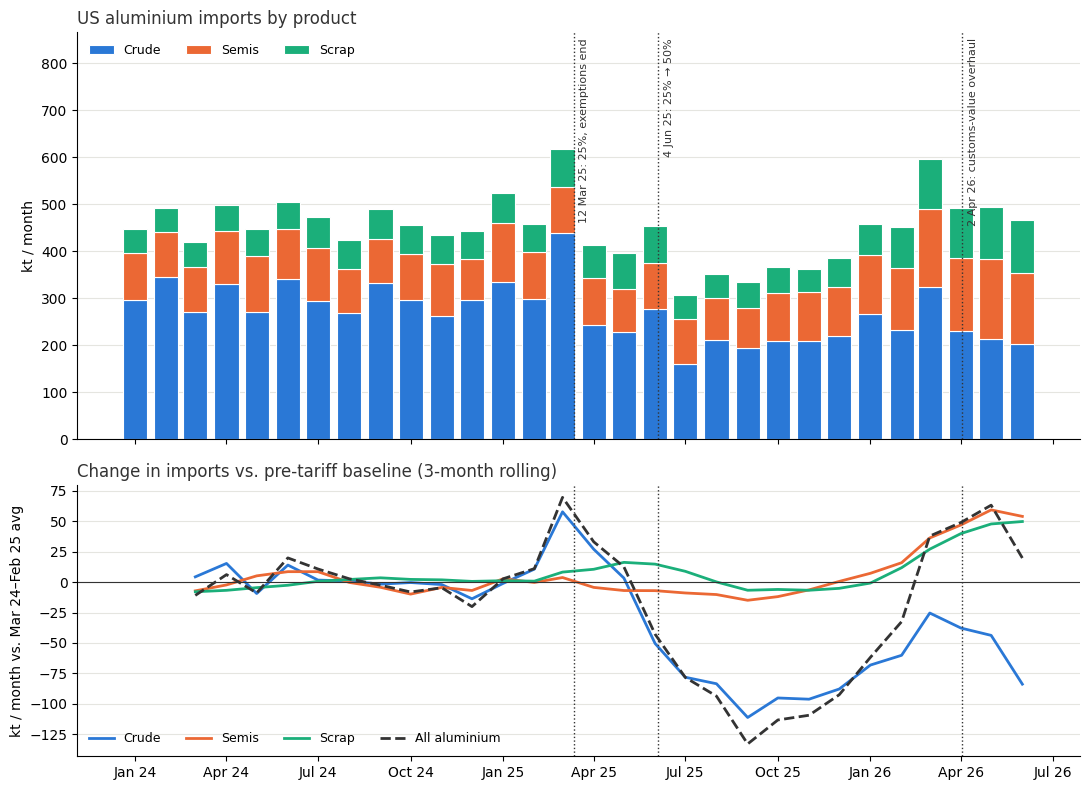

,Mar 24–Feb 25 (Canada 0%),Mar 25 (front-running),Apr–May 25 (25%),Jul 25–Mar 26 (50%),"Apr–Jun 26 (50%, new valuation)",50% vs. baseline (kt)
Crude,299.4,438.0,235.0,224.7,215.7,-74.7
Semis,104.5,98.6,97.0,111.7,158.3,7.2
Scrap,60.0,81.5,73.5,65.1,109.7,5.1
All aluminium,464.0,618.1,405.5,401.5,483.7,-62.5
Crude share (%),65.0,71.0,58.0,56.0,45.0,NaN


In [10]:
# US aluminium imports by product: crude (unwrought) vs. semis vs. scrap, all origins
by_product = (imports[imports["country"] == "Total"].set_index("date")
              [["crude_t", "semis_t", "scrap_t"]]
              .rename(columns={"crude_t": "Crude", "semis_t": "Semis", "scrap_t": "Scrap"})
              .loc["2024-01-01":] / 1e3)   # kt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})

bottom = pd.Series(0.0, index=by_product.index)
for col, color in zip(by_product.columns, SERIES_COLORS):
    ax1.bar(by_product.index, by_product[col], bottom=bottom, width=24, color=color,
            edgecolor="white", linewidth=0.8, label=col)
    bottom += by_product[col]
ax1.set_ylabel("kt / month")
ax1.set_title("US aluminium imports by product", loc="left", color=INK)
ax1.set_ylim(0, by_product.sum(axis=1).max() * 1.4)
ax1.legend(loc="upper left", frameon=False, fontsize=9, ncol=3)

# Change vs. pre-tariff baseline (12 months to Feb 2025), 3-month rolling, in kt so the products add up
prod = by_product.assign(**{"All aluminium": by_product.sum(axis=1)})
base_prod = prod.loc["2024-03-01":"2025-02-01"].mean()
chg_prod = prod.rolling(3).mean() - base_prod
for col, color, ls in zip(chg_prod.columns, SERIES_COLORS[:3] + [INK], ["-", "-", "-", "--"]):
    ax2.plot(chg_prod.index, chg_prod[col], color=color, lw=2, ls=ls, label=col)
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("kt / month vs. Mar 24–Feb 25 avg")
ax2.set_title("Change in imports vs. pre-tariff baseline (3-month rolling)", loc="left", color=INK)
ax2.legend(loc="lower left", frameon=False, fontsize=9, ncol=4)

for ax in (ax1, ax2):
    for d in EVENTS:
        ax.axvline(d, color=INK, lw=1, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d, label in EVENTS.items():
    ax1.annotate(label, xy=(d, ax1.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
                 fontsize=8, color=INK, rotation=90, va="top")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Average monthly imports (kt) by product in each tariff regime (same windows as the by-origin table)
regimes_prod = pd.DataFrame({k: prod.loc[a:b].mean() for k, (a, b) in WINDOWS.items()}).round(1)
regimes_prod.loc["Crude share (%)"] = (regimes_prod.loc["Crude"] / regimes_prod.loc["All aluminium"] * 100).round(0)
regimes_prod["50% vs. baseline (kt)"] = (regimes_prod["Jul 25–Mar 26 (50%)"] - regimes_prod["Mar 24–Feb 25 (Canada 0%)"]).round(1)
regimes_prod.loc["Crude share (%)", "50% vs. baseline (kt)"] = None
regimes_prod

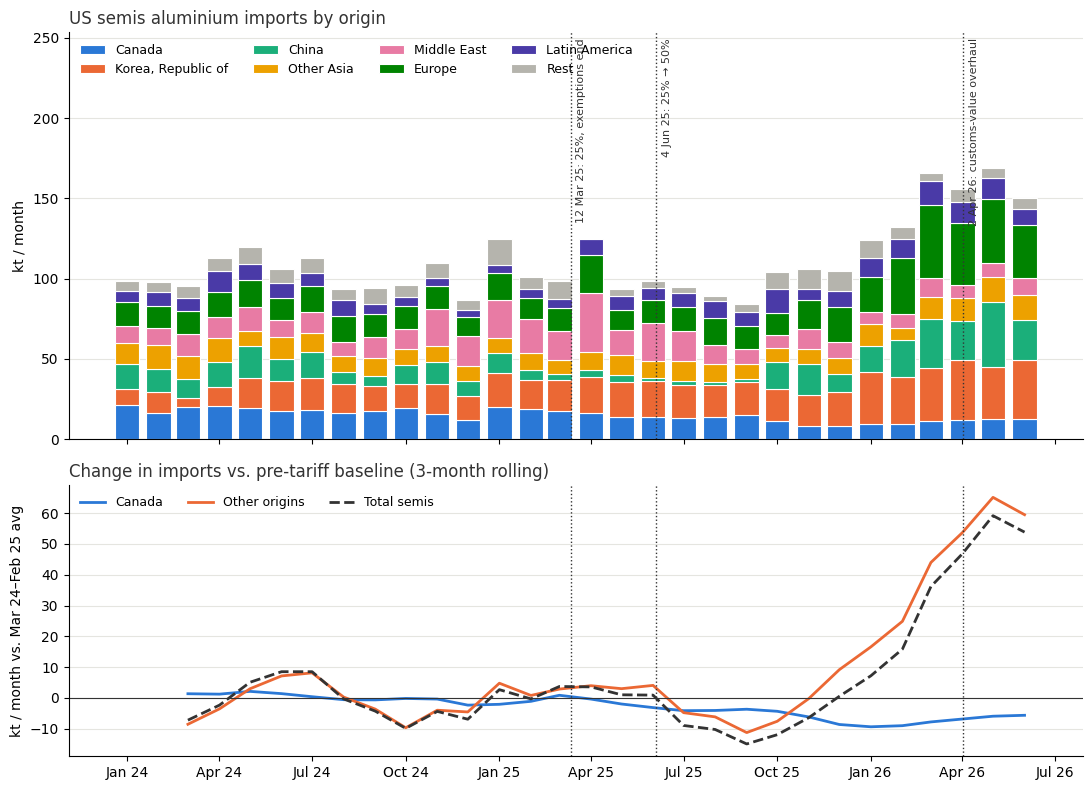

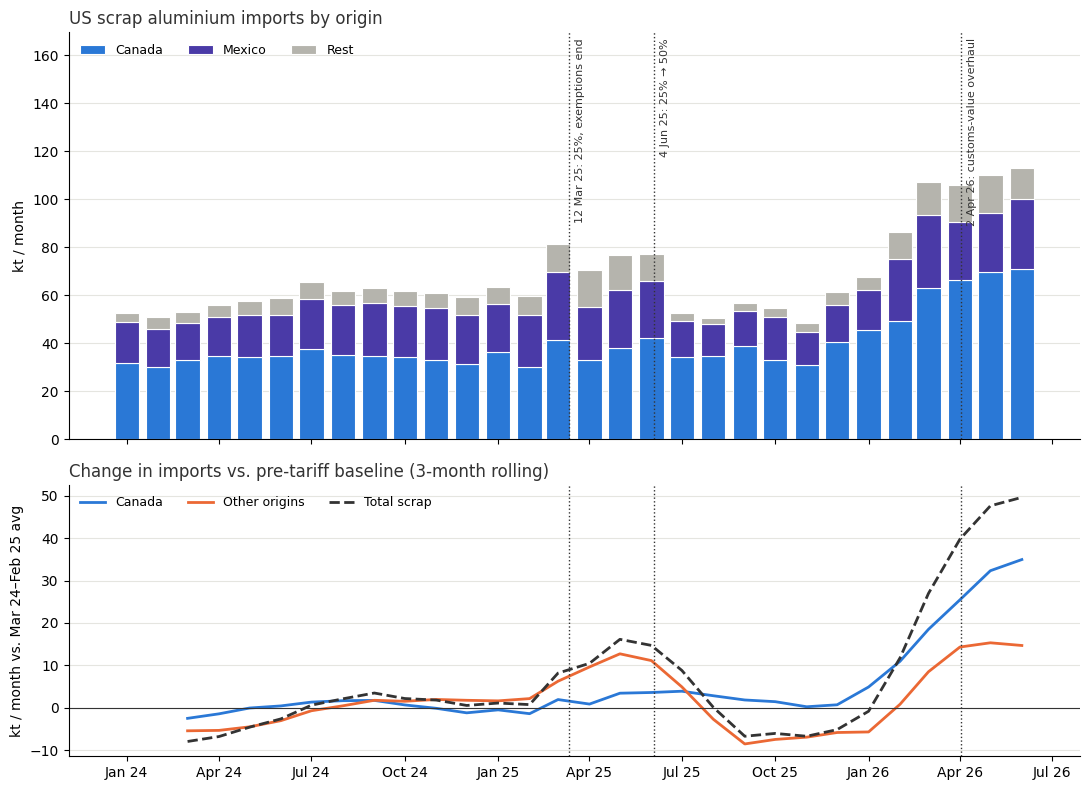

Mar 24–Feb 25 (Canada 0%)  Mar 25 (front-running)  \
      country                                                                 
Semis Canada                                   17.9                    17.6   
      Korea, Republic of                       16.5                    19.3   
      China                                    11.9                     3.7   
      Other Asia                               11.2                     8.6   
      Middle East                              15.5                    18.1   
      Europe                                   14.8                    14.5   
      Latin America                             7.5                     5.7   
      Rest                                      9.1                    11.1   
      Total                                   104.5                    98.6   
Scrap Canada                                   34.1                    41.5   
      Mexico                                   19.5                    28.1   
      Rest                                      6.4                    11.9   
      Total                                    60.0                    81.5   

                          Apr–May 25 (25%)  Jul 25–Mar 26 (50%)  \
      country                                                     
Semis Canada                          15.1                 11.2   
      Korea, Republic of              22.2                 23.9   
      China                            4.4                 13.8   
      Other Asia                      11.9                 10.7   
      Middle East                     25.9                 10.9   
      Europe                          18.5                 22.4   
      Latin America                    9.0                 11.0   
      Rest                             2.2                  7.9   
      Total                          108.9                111.7   
Scrap Canada                          35.5                 41.1   
      Mexico                          23.2                 18.1   
      Rest                            14.8                  5.9   
      Total                           73.5                 65.1   

                          Apr–Jun 26 (50%, new valuation)  \
      country                                               
Semis Canada                                         12.3   
      Korea, Republic of                             35.6   
      China                                          29.9   
      Other Asia                                     15.1   
      Middle East                                     9.4   
      Europe                                         36.9   
      Latin America                                  12.1   
      Rest                                            7.1   
      Total                                         158.3   
Scrap Canada                                         69.0   
      Mexico                                         25.8   
      Rest                                           14.8   
      Total                                         109.7   

                          50% vs. baseline (kt)  
      country                                    
Semis Canada                               -6.7  
      Korea, Republic of                    7.4  
      China                                 1.9  
      Other Asia                           -0.5  
      Middle East                          -4.6  
      Europe                                7.6  
      Latin America                         3.5  
      Rest                                 -1.2  
      Total                                 7.2  
Scrap Canada                                7.0  
      Mexico                               -1.4  
      Rest                                 -0.5  
      Total                                 5.1

In [11]:
# US semis and scrap imports by origin, same layout as the crude chart
# Semis are fragmented (~20 origins at 1-3% each), so beyond the three largest suppliers they are grouped by region.
# Scrap is almost all Canada + Mexico. "Other" is USGS's own unallocated bucket.
REGIONS = {
    "Other Asia":     ["Japan", "Taiwan", "Hong Kong", "Thailand", "Vietnam", "Indonesia", "Malaysia", "India"],
    "Middle East":    ["Oman", "Saudi Arabia", "Bahrain", "United Arab Emirates", "Qatar", "Turkey", "Azerbaijan"],
    "Europe":         ["Germany", "Greece", "Austria", "Belgium", "Sweden", "Spain", "United Kingdom", "Switzerland",
                       "Italy", "France", "Netherlands", "Norway", "Romania", "Poland", "Russia"],
    "Latin America":  ["Mexico", "Brazil", "Argentina", "Chile", "Colombia", "Costa Rica", "Ecuador",
                       "Guatemala", "Honduras", "Panama"],
}
PRODUCTS = {"semis_t": ("Semis", ["Canada", "Korea, Republic of", "China"], True),   # (label, named origins, group the rest by region)
            "scrap_t": ("Scrap", ["Canada", "Mexico"], False)}

# One colour per series across both figures; Canada keeps the blue it has in the crude chart.
# Mexico shares Latin America's colour since it is the bulk of that group.
COUNTRY_COLORS = {"Canada": "#2a78d6", "Korea, Republic of": "#eb6834", "China": "#1baf7a",
                  "Other Asia": "#eda100", "Middle East": "#e87ba4", "Europe": "#008300",
                  "Latin America": "#4a3aa7", "Mexico": "#4a3aa7", "Rest": "#b5b4ad"}

product_tables = {}
for col, (label, named, by_region) in PRODUCTS.items():
    by_country = (imports[imports["country"] != "Total"]
                  .pivot_table(index="date", columns="country", values=col, aggfunc="sum").fillna(0))
    total_p = imports[imports["country"] == "Total"].set_index("date")[col]
    fl = by_country[named].copy()
    if by_region:
        for region, members in REGIONS.items():
            fl[region] = by_country[[m for m in members if m in by_country and m not in named]].sum(axis=1)
    # Residual so the stack equals the reported total. Clipped at 0: in Apr 2025 (derived from YTD differences)
    # the semis country rows sum to ~25 kt more than the reported total, which would give a negative bar.
    fl["Rest"] = (total_p - fl.sum(axis=1)).clip(lower=0)
    fl = fl.loc["2024-01-01":] / 1e3        # kt

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                                   gridspec_kw={"height_ratios": [3, 2]})
    bottom = pd.Series(0.0, index=fl.index)
    for c in fl.columns:
        ax1.bar(fl.index, fl[c], bottom=bottom, width=24, color=COUNTRY_COLORS[c],
                edgecolor="white", linewidth=0.8, label=c)
        bottom += fl[c]
    ax1.set_ylabel("kt / month")
    ax1.set_title(f"US {label.lower()} aluminium imports by origin", loc="left", color=INK)
    ax1.set_ylim(0, fl.sum(axis=1).max() * 1.5)
    ax1.legend(loc="upper left", frameon=False, fontsize=9, ncol=4)

    # Change vs. pre-tariff baseline (12 months to Feb 2025), 3-month rolling, in kt
    g = pd.DataFrame({"Canada": fl["Canada"], "Other origins": fl.drop(columns="Canada").sum(axis=1)})
    g[f"Total {label.lower()}"] = g.sum(axis=1)
    chg = g.rolling(3).mean() - g.loc["2024-03-01":"2025-02-01"].mean()
    for c, color, ls in zip(chg.columns, [BLUE, ORANGE, INK], ["-", "-", "--"]):
        ax2.plot(chg.index, chg[c], color=color, lw=2, ls=ls, label=c)
    ax2.axhline(0, color=INK, lw=0.8)
    ax2.set_ylabel("kt / month vs. Mar 24–Feb 25 avg")
    ax2.set_title("Change in imports vs. pre-tariff baseline (3-month rolling)", loc="left", color=INK)
    ax2.legend(loc="upper left", frameon=False, fontsize=9, ncol=3)

    for ax in (ax1, ax2):
        for d in EVENTS:
            ax.axvline(d, color=INK, lw=1, ls=":")
        ax.grid(axis="y", color="#e5e5e0", lw=0.8)
        ax.set_axisbelow(True)
        ax.spines[["top", "right"]].set_visible(False)
    for d, txt in EVENTS.items():
        ax1.annotate(txt, xy=(d, ax1.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
                     fontsize=8, color=INK, rotation=90, va="top")
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    fig.tight_layout()
    plt.show()

    t = fl.assign(**{"Total": fl.sum(axis=1)})
    product_tables[label] = pd.DataFrame({k: t.loc[a:b].mean() for k, (a, b) in WINDOWS.items()})

# Average monthly imports (kt) by origin in each tariff regime (same windows as the crude table)
regimes_sp = pd.concat(product_tables).round(1)
regimes_sp["50% vs. baseline (kt)"] = (regimes_sp["Jul 25–Mar 26 (50%)"] - regimes_sp["Mar 24–Feb 25 (Canada 0%)"]).round(1)
regimes_sp

Semis and scrap imports have risen in order to make up for the fall in the crude.

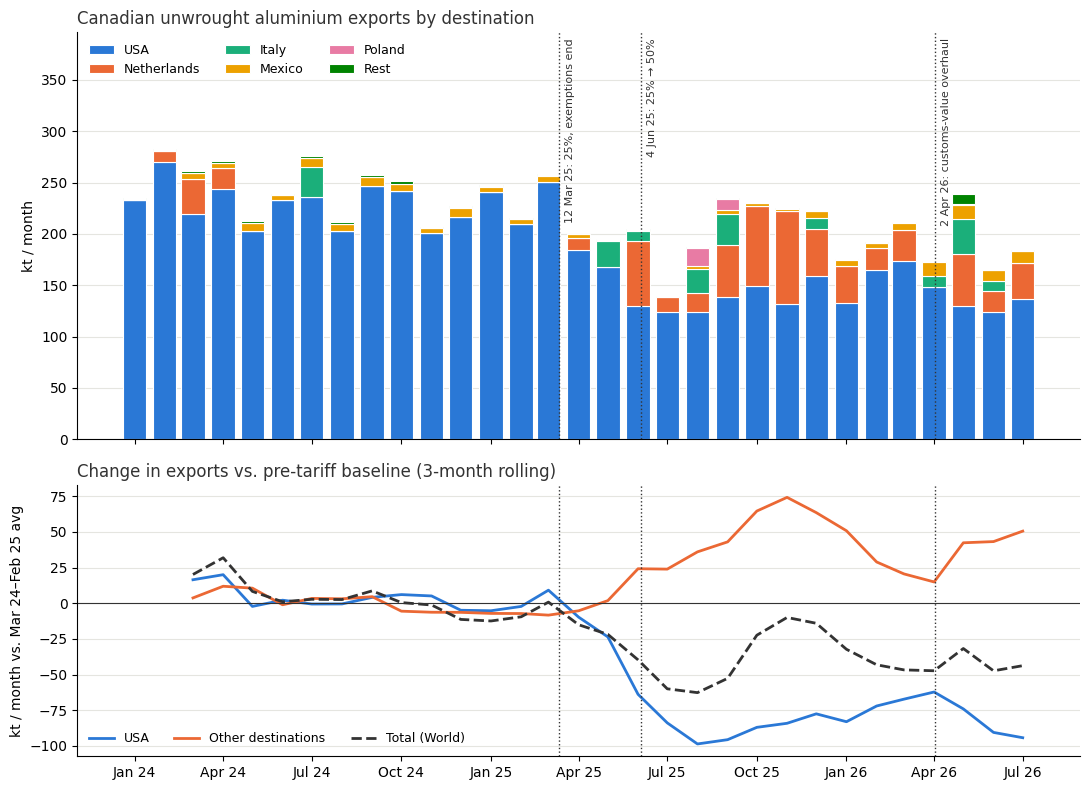

,Mar 24–Feb 25 (Canada 0%),Mar 25 (front-running),Apr–May 25 (25%),Jul 25–Mar 26 (50%),"Apr–Jul 26 (50%, new valuation)",50% vs. baseline (kt)
country,,,,,,
USA,224.4,250.5,175.8,144.2,134.6,-80.2
Netherlands,4.5,0.0,5.9,42.8,26.5,38.3
Italy,2.5,0.0,12.7,7.0,13.8,4.5
Mexico,6.6,6.1,2.3,4.2,12.4,-2.4
Poland,0.3,0.7,0.4,3.4,0.2,3.1
Rest,1.5,0.7,0.5,0.3,2.8,-1.2
Total (World),239.7,258.1,197.8,201.9,190.3,-37.8
US share (%),94.0,97.0,89.0,71.0,71.0,NaN


In [12]:
# Canadian unwrought aluminium exports (HS 7601) by destination around the tariff steps
ca = pd.read_csv(CANADA_EXPORTS, parse_dates=["date"])
ca = ca[ca["hs"] == 7601]   # HS 7602 (scrap) only runs to Oct 2024

exports = (ca[ca["country"] != "World"]
           .pivot_table(index="date", columns="country", values="tonnes", aggfunc="sum")
           .fillna(0))
world = ca[ca["country"] == "World"].set_index("date")["tonnes"]

# Main destinations: the largest since 2024; everything else folds into "Rest"
TOP_N = 4
dest = (exports.loc["2024-01-01":].sum()
        .sort_values(ascending=False).index[:TOP_N + 1].tolist())   # USA + next 4
ex = exports[dest].copy()
ex["Rest"] = world - ex.sum(axis=1)   # residual so the stack equals the reported World total
ex = ex.loc["2024-01-01":] / 1e3      # kt

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})

bottom = pd.Series(0.0, index=ex.index)
for col, color in zip(ex.columns, SERIES_COLORS):
    ax1.bar(ex.index, ex[col], bottom=bottom, width=24, color=color,
            edgecolor="white", linewidth=0.8, label=col)
    bottom += ex[col]
ax1.set_ylabel("kt / month")
ax1.set_title("Canadian unwrought aluminium exports by destination", loc="left", color=INK)
ax1.set_ylim(0, ex.sum(axis=1).max() * 1.4)
ax1.legend(loc="upper left", frameon=False, fontsize=9, ncol=3)

# Change vs. pre-tariff baseline (12 months to Feb 2025), 3-month rolling, by group.
# In kt rather than %: non-US destinations start from ~15 kt/month, so their % change is huge and uninformative
groups_ca = pd.DataFrame({"USA": ex["USA"],
                          "Other destinations": ex.drop(columns="USA").sum(axis=1)})
groups_ca["Total (World)"] = groups_ca.sum(axis=1)
base_ca = groups_ca.loc["2024-03-01":"2025-02-01"].mean()
chg_ca = groups_ca.rolling(3).mean() - base_ca
for col, color, ls in zip(chg_ca.columns, [BLUE, ORANGE, INK], ["-", "-", "--"]):
    ax2.plot(chg_ca.index, chg_ca[col], color=color, lw=2, ls=ls, label=col)
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("kt / month vs. Mar 24–Feb 25 avg")
ax2.set_title("Change in exports vs. pre-tariff baseline (3-month rolling)", loc="left", color=INK)
ax2.legend(loc="lower left", frameon=False, fontsize=9, ncol=3)

for ax in (ax1, ax2):
    for d in EVENTS:
        ax.axvline(d, color=INK, lw=1, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d, label in EVENTS.items():
    ax1.annotate(label, xy=(d, ax1.get_ylim()[1]), xytext=(4, -4), textcoords="offset points",
                 fontsize=8, color=INK, rotation=90, va="top")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Average monthly exports (kt) in each tariff regime, full months only
WINDOWS_CA = {
    "Mar 24–Feb 25 (Canada 0%)":       ("2024-03-01", "2025-02-01"),
    "Mar 25 (front-running)":          ("2025-03-01", "2025-03-01"),
    "Apr–May 25 (25%)":                ("2025-04-01", "2025-05-01"),
    "Jul 25–Mar 26 (50%)":             ("2025-07-01", "2026-03-01"),
    "Apr–Jul 26 (50%, new valuation)": ("2026-04-01", "2026-07-01"),
}
table_ca = ex.assign(**{"Total (World)": ex.sum(axis=1)})
regimes_ca = pd.DataFrame({k: table_ca.loc[a:b].mean() for k, (a, b) in WINDOWS_CA.items()}).round(1)
regimes_ca.loc["US share (%)"] = (regimes_ca.loc["USA"] / regimes_ca.loc["Total (World)"] * 100).round(0)
regimes_ca["50% vs. baseline (kt)"] = (regimes_ca["Jul 25–Mar 26 (50%)"] - regimes_ca["Mar 24–Feb 25 (Canada 0%)"]).round(1)
regimes_ca.loc["US share (%)", "50% vs. baseline (kt)"] = None
regimes_ca

**Note: the daily curve is the LME's thinly traded MW contract.** `midwest_premium_curve.csv` comes from the LME Aluminium Premium Duty Paid US Midwest (Platts) contract. Most of the volume on the same Platts assessment trades on CME instead (Aluminum MW U.S. Transaction Premium Platts futures, code AUP). Signs of staleness in this file:
- Since 2024, M01 is unchanged on 42% of trading days, and M02, M03 and M06 on 81–82%.
- Around the August 2026 Canada news, the file shows the Sep-26 contract at 2,400 \$/t until 21 Aug and 2,300 from 24 Aug (−4%, two business days after the CME move, and after the deal had already collapsed). The press reported the CME September contract down 8.2% to 95 c/lb (≈ 2,094 \$/t) on Thursday 20 Aug, with Oct and Nov down more than 12% ([AEGIS, 21 Aug 2026](https://aegis-hedging.com/insights/metals/daily-first-look/2026-08-21)).

What this means: month-end samples are usable, because M01 is pinned by the month's fixings and the forecast test below flags stale M03 quotes. Daily event windows (the Δ +5d / Δ +20d table) and the weekly tests in the hedge-ratio section understate and delay moves. TODO: source CME AUP settlements and re-run the event table and the weekly tests on them.

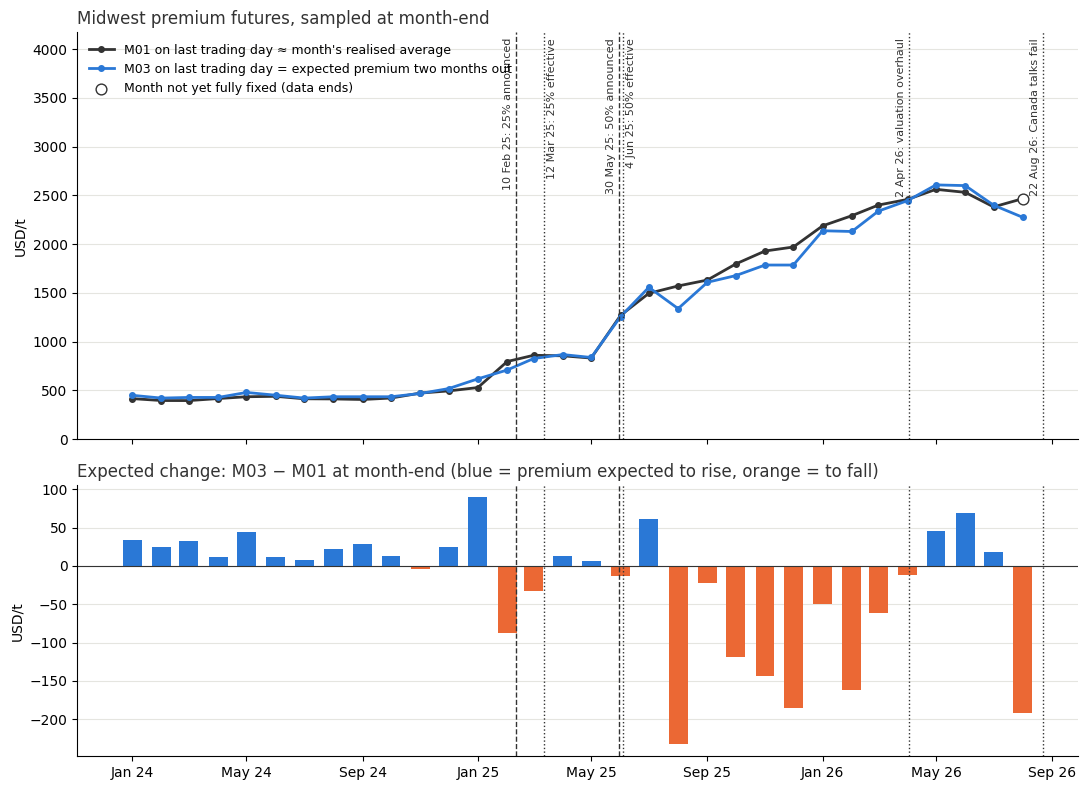

In [13]:
# MW premium curve sampled once a month, on the last trading day.
# Each contract settles on the average of that month's daily Platts assessments, so M01 is part-fixed during the
# month and only at month-end equals the month's (nearly) realised average. Sampling on that day makes the slope
# read cleanly: M03 − M01 = premium the market expects two months out − this month's realised average.
# A daily M03 − M01 instead mixes a part-fixed average with a forecast, and jumps every time M01 rolls.
# Caveat: M02+ are unchanged on ~80% of days since 2024 and often equal each other, so M03 is a coarse forecast.
curve = mwp_futures.pivot(index="date", columns="tenor", values="premium_usd_t").loc["2024-01-01":]

CURVE_EVENTS = {   # (label, line style, label side): dashed = announcement, dotted = effective date
    pd.Timestamp("2025-02-10"): ("10 Feb 25: 25% announced", "--", "left"),
    pd.Timestamp("2025-03-12"): ("12 Mar 25: 25% effective", ":", "right"),
    pd.Timestamp("2025-05-30"): ("30 May 25: 50% announced", "--", "left"),
    TARIFF_DATE:                ("4 Jun 25: 50% effective", ":", "right"),
    pd.Timestamp("2026-04-02"): ("2 Apr 26: valuation overhaul", ":", "left"),
    pd.Timestamp("2026-08-22"): ("22 Aug 26: Canada talks fail", ":", "left"),
}

last_day = curve.groupby(curve.index.to_period("M")).tail(1)
me = pd.DataFrame({"realised": last_day[1].values, "m03": last_day[3].values,
                   "trade_date": last_day.index}, index=last_day.index.to_period("M").to_timestamp())
me["slope"] = me["m03"] - me["realised"]
# The data ends mid-month (28 Aug 26 is not the last business day of August), so the last month is not fully fixed.
# Only the last row is checked: earlier months can end before the business month-end on holidays (Good Friday).
partial = pd.Series(False, index=me.index)
partial.iloc[-1] = me["trade_date"].iloc[-1] < me.index[-1] + pd.offsets.BMonthEnd(0)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})
ax1.plot(me.index, me["realised"], color=INK, lw=2, marker="o", ms=4,
         label="M01 on last trading day ≈ month's realised average")
ax1.plot(me.index, me["m03"], color=BLUE, lw=2, marker="o", ms=4,
         label="M03 on last trading day = expected premium two months out")
if partial.any():
    ax1.scatter(me.index[partial], me.loc[partial, "realised"], s=60, facecolors="white", edgecolors=INK, zorder=3,
                label="Month not yet fully fixed (data ends)")
ax1.set_ylabel("USD/t")
ax1.set_title("Midwest premium futures, sampled at month-end", loc="left", color=INK)
ax1.set_ylim(0, me[["realised", "m03"]].max().max() * 1.6)
ax1.legend(loc="upper left", frameon=False, fontsize=9)

ax2.bar(me.index, me["slope"], width=20, color=[BLUE if s >= 0 else ORANGE for s in me["slope"]])
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("USD/t")
ax2.set_title("Expected change: M03 − M01 at month-end (blue = premium expected to rise, orange = to fall)",
              loc="left", color=INK)

for ax in (ax1, ax2):
    for d, (_, ls, _) in CURVE_EVENTS.items():
        ax.axvline(d, color=INK, lw=1, ls=ls)
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d, (label, _, side) in CURVE_EVENTS.items():
    ax1.annotate(label, xy=(d, ax1.get_ylim()[1]), xytext=(-2 if side == "left" else 2, -4),
                 textcoords="offset points", fontsize=8, color=INK, rotation=90, va="top",
                 ha="right" if side == "left" else "left")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()


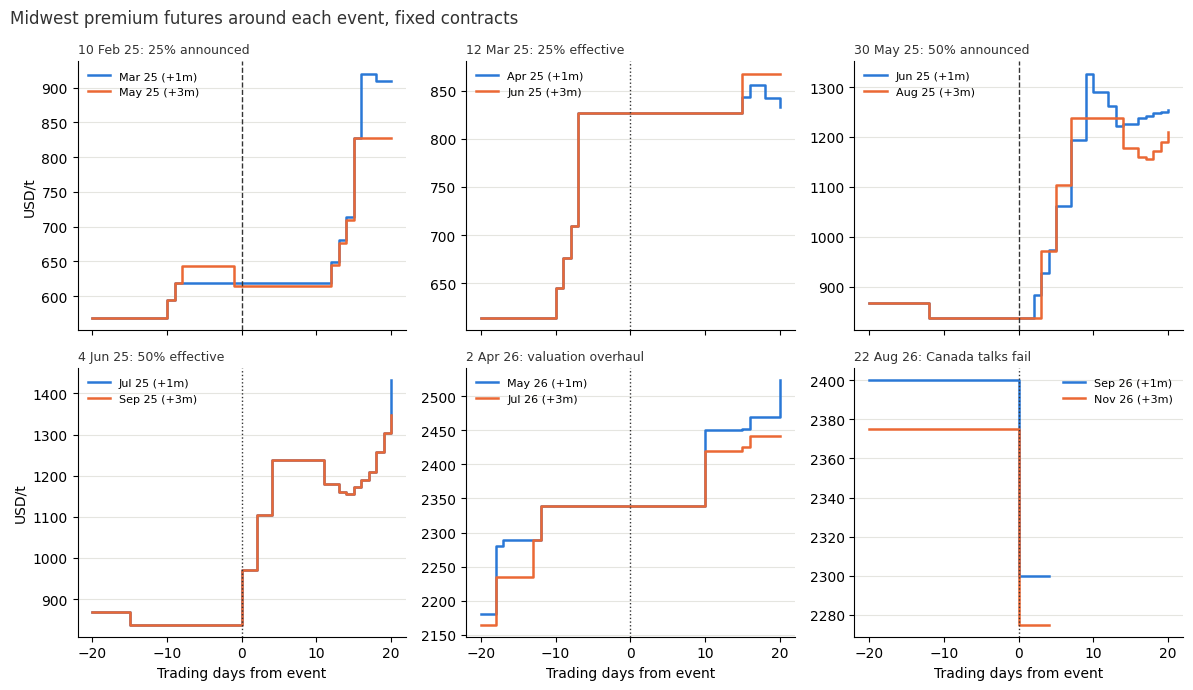

+1m                              +3m  \
                             contract   before  Δ +5d  Δ +20d contract   
10 Feb 25: 25% announced       Mar 25   618.98    0.0  290.48   May 25   
12 Mar 25: 25% effective       Apr 25   827.23    0.0    5.97   Jun 25   
30 May 25: 50% announced       Jun 25    838.0  223.0  415.01   Aug 25   
4 Jun 25: 50% effective        Jul 25    838.0  399.0   593.9   Sep 25   
2 Apr 26: valuation overhaul   May 26  2339.24    0.0  183.95   Jul 26   
22 Aug 26: Canada talks fail   Sep 26   2400.0    NaN     NaN   Nov 26   

                                                      
                               before  Δ +5d  Δ +20d  
10 Feb 25: 25% announced       613.98    0.0  213.25  
12 Mar 25: 25% effective       827.23    0.0   40.77  
30 May 25: 50% announced        838.0  266.0  372.12  
4 Jun 25: 50% effective         838.0  399.0  510.35  
2 Apr 26: valuation overhaul  2339.24    0.0  101.76  
22 Aug 26: Canada talks fail   2375.0    NaN     NaN

In [14]:
# Event windows on FIXED contracts. The rolling M01/M03 columns switch contract on the first trading day of each
# month, and M01 is part-fixed by the month's assessments, so they mix contracts and damp jumps.
# Instead follow the contracts for event month +1 (no days fixed yet) and +3, 20 trading days either side.
by_contract = (mwp_futures.assign(contract_month=pd.to_datetime(mwp_futures["contract_month"]))
               .pivot_table(index="date", columns="contract_month", values="premium_usd_t"))
WINDOW = 20   # trading days either side

fig, axes = plt.subplots(2, 3, figsize=(12, 7), sharex=True)
for ax, (d, (label, ls, _)) in zip(axes.flat, CURVE_EVENTS.items()):
    for ahead, color in [(1, BLUE), (3, ORANGE)]:
        cm = (d.to_period("M") + ahead).to_timestamp()
        s_ = by_contract[cm].dropna()
        i = s_.index.searchsorted(d)   # first trading day on/after the date
        win = s_.iloc[max(i - WINDOW, 0): i + WINDOW + 1]
        x = range(-min(i, WINDOW), -min(i, WINDOW) + len(win))
        ax.step(list(x), win.values, where="post", color=color, lw=1.8, label=f"{cm:%b %y} (+{ahead}m)")
    ax.axvline(0, color=INK, lw=1, ls=ls)
    ax.set_title(label, loc="left", fontsize=9, color=INK)
    ax.legend(loc="best", frameon=False, fontsize=8)
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for ax in axes[1]:
    ax.set_xlabel("Trading days from event")
for ax in axes[:, 0]:
    ax.set_ylabel("USD/t")
fig.suptitle("Midwest premium futures around each event, fixed contracts", x=0.01, ha="left", color=INK)
fig.tight_layout()
plt.show()

def settle_around(series, date, offset):
    series = series.dropna()
    i = series.index.searchsorted(date)   # first trading day on/after the date
    if offset < 0:
        return series.iloc[i - 1]
    return series.iloc[i + offset] if i + offset < len(series) else float("nan")   # past the end of the data

rows = {}
for d, (label, _, _) in CURVE_EVENTS.items():
    r_ = {}
    for ahead in (1, 3):
        cm = (d.to_period("M") + ahead).to_timestamp()
        s_ = by_contract[cm]
        before = settle_around(s_, d, -1)
        key = f"+{ahead}m"
        r_[(key, "contract")] = f"{cm:%b %y}"
        r_[(key, "before")] = before
        r_[(key, "Δ +5d")] = settle_around(s_, d, 5) - before
        r_[(key, "Δ +20d")] = settle_around(s_, d, 20) - before
    rows[label] = r_
event_moves = pd.DataFrame(rows).T
event_moves.columns = pd.MultiIndex.from_tuples(event_moves.columns)
event_moves


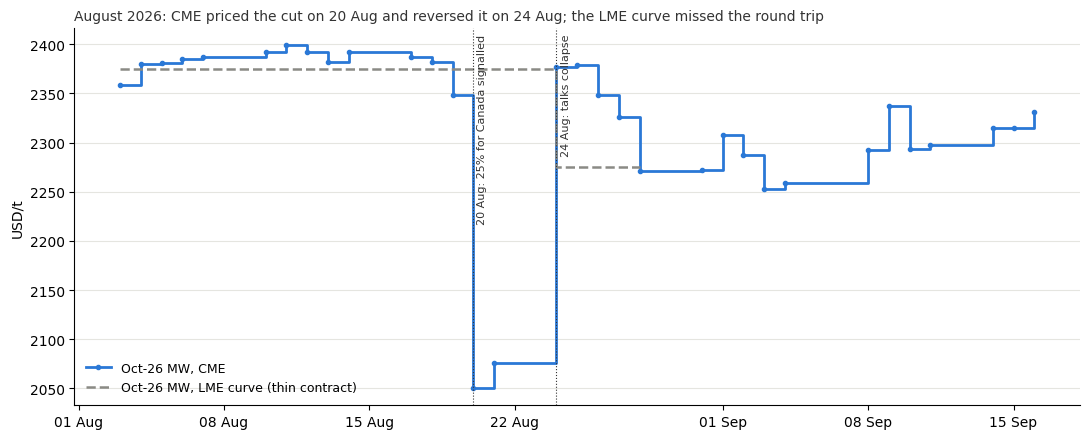

18 Aug  Δ to 20 Aug  Δ to 21 Aug  Δ to 24 Aug  Δ to 28 Aug  \
CME       Sep 26  2398.0       -303.0       -298.0        -12.0        -50.0   
          Oct 26  2382.0       -331.0       -305.0         -4.0       -111.0   
          Nov 26  2382.0       -332.0       -308.0        -23.0       -177.0   
LME curve Sep 26  2400.0          0.0          0.0       -100.0       -100.0   
          Oct 26  2375.0          0.0          0.0       -100.0       -100.0   
          Nov 26  2375.0          0.0          0.0       -100.0       -100.0   

                  Δ to 16 Sep  
CME       Sep 26         17.0  
          Oct 26        -50.0  
          Nov 26       -100.0  
LME curve Sep 26          NaN  
          Oct 26          NaN  
          Nov 26          NaN

In [15]:
# The event table above on CME settlements. The LME curve is the thin contract (see the note above), so redo the August
# 2026 episode on the CME contracts one, two and three months out (Sep, Oct, Nov 26), the CME contracts on hand. Earlier
# events can't be redone: in 2025 the only CME contract on hand, Oct-26, was more than a year out and barely traded.
# Moves are cumulative from the 18 Aug settlement, the last before the news (Sep-26 already fell 116 $/t on 19 Aug), to:
# 20 Aug (US signals 25% for Canada), 21 Aug, 24 Aug (first settlement after the talks collapsed), 28 Aug (the LME curve's
# last day) and 16 Sep (20 trading days after 18 Aug). The LME curve's settlements for the same contracts are alongside.
cme_ev = pd.read_csv(Path.cwd() / "data" / "midwest_premium_cme.csv", parse_dates=["date", "contract_month"])
cme_ev = cme_ev.pivot_table(index="date", columns="contract_month", values="premium_usd_t")
EV_BASE = pd.Timestamp("2026-08-18")
EV_DAYS = {"20 Aug": "2026-08-20", "21 Aug": "2026-08-21", "24 Aug": "2026-08-24", "28 Aug": "2026-08-28",
           "16 Sep": "2026-09-16"}
EV_CONTRACTS = pd.to_datetime(["2026-09-01", "2026-10-01", "2026-11-01"])

aug_rows = {}
for src, table in [("CME", cme_ev), ("LME curve", by_contract)]:
    for cm in EV_CONTRACTS:
        s_ = table[cm].dropna()
        row = {"18 Aug": s_.loc[EV_BASE]}
        for label, d in EV_DAYS.items():
            row[f"Δ to {label}"] = s_.loc[d] - s_.loc[EV_BASE] if pd.Timestamp(d) in s_.index else float("nan")
        aug_rows[(src, f"{cm:%b %y}")] = row
aug_moves = pd.DataFrame(aug_rows).T

fig, ax = plt.subplots(figsize=(11, 4.5))
for src, table, color, kw in [("CME", cme_ev, BLUE, {"lw": 2, "marker": "o", "ms": 3}),
                              ("LME curve (thin contract)", by_contract, MUTED, {"lw": 1.8, "ls": "--"})]:
    s_ = table[pd.Timestamp("2026-10-01")].loc["2026-08-03":"2026-09-16"].dropna()
    ax.step(s_.index, s_.values, where="post", color=color, label=f"Oct-26 MW, {src}", **kw)
for d0, label in [("2026-08-20", "20 Aug: 25% for Canada signalled"), ("2026-08-24", "24 Aug: talks collapse")]:
    ax.axvline(pd.Timestamp(d0), color=INK, lw=0.8, ls=":")
    ax.annotate(label, xy=(pd.Timestamp(d0), ax.get_ylim()[1]), xytext=(3, -4), textcoords="offset points", fontsize=8,
                color=INK, rotation=90, va="top", ha="left")
ax.set_ylabel("USD/t")
ax.set_title("August 2026: CME priced the cut on 20 Aug and reversed it on 24 Aug; the LME curve missed the round trip",
             loc="left", color=INK, fontsize=10)
ax.legend(loc="lower left", frameon=False, fontsize=9)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.grid(axis="y", color="#e5e5e0", lw=0.8)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
plt.show()

aug_moves.round(0)

Takeaway (August 2026 on CME):
- **CME priced the cut and its reversal within four trading days.** From the 18 Aug settlement to 20 Aug, the Sep-26, Oct-26 and Nov-26 contracts fell 303, 331 and 332 \$/t. Sep-26 had already fallen 116 \$/t on 19 Aug. By 24 Aug, after the talks collapsed, all three were back within 25 \$/t of their 18 Aug level. The 331 \$/t on Oct-26 is about a third of the 921 \$/t fall in Canada parity at a Canada-only 25%. That fits the market pricing either a partial chance of the deal or a smaller effect than full Canada parity; one event can't separate the two (see the supply-stack note).
- **The LME curve missed the round trip.** Its Sep-26 to Nov-26 settlements didn't move on 20–21 Aug. They fell a flat 100 \$/t on 24 Aug, the day CME recovered, and stayed there to the end of the file (28 Aug). The table above records the episode as a 100 \$/t fall rather than a 330 \$/t drop and recovery. This is the clearest case of caveat 2, and the reason the risk section uses CME.
- **After the round trip, the curve tilted.** By 16 Sep, Sep-26 was 17 \$/t above its 18 Aug level, Oct-26 50 below and Nov-26 100 below, while LME 3M rose 55 \$/t (about +28 at t = 50%). The further-out contracts fell 80–130 \$/t more than LME implies. That is the backwardation seen through the 50% regime (the curve pricing relief later on), now on liquid settlements. Two weeks of three contracts is a description, not a test.
- **The earlier events can't be redone on CME.** In 2025 the only contract on hand, Oct-26, was more than a year out and unchanged on 60–90% of days. The 2025 rows of the table above stay on the LME curve, with its staleness caveat.

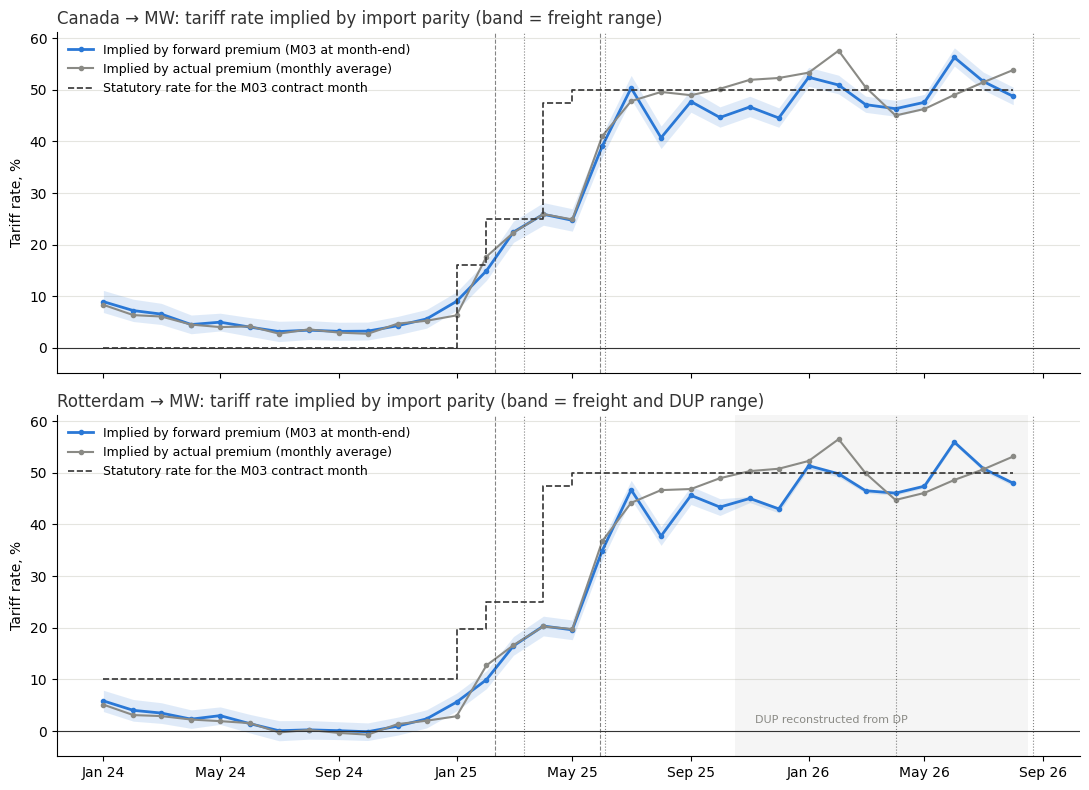

actual  forward  expected change
Canada    Jan 24–Jan 25 (Canada 0%)     4.8      5.3              0.5
          Apr–May 25 (25%)             25.4     25.3             -0.1
          Jul–Dec 25 (50%)             50.1     45.8             -4.4
          Jan–Aug 26 (50%)             50.9     50.1             -0.8
Rotterdam Jan 24–Jan 25 (Canada 0%)     1.7      2.2              0.6
          Apr–May 25 (25%)             20.0     20.0             -0.0
          Jul–Dec 25 (50%)             48.0     43.6             -4.4
          Jan–Aug 26 (50%)             50.3     49.5             -0.8

In [15]:
# Implied tariff rate: the rate at which import parity explains the MW premium.
# Parity premium at tariff t (landed cost − LME, as in the route model above):
#   Canada:    MWP* = (DP − F_netback) + F_ca_mw + t × (LME + DP − F_netback)
#   Rotterdam: MWP* = DUP + F_rtm_mw + t × (LME + DUP)
# Solved for t, once with the actual premium (monthly average, LME cash) and once with the forward premium
# (M03 on the last trading day, LME 3M on that day; DP / DUP held at this month's level, no forward exists).
#   forward-implied < actual-implied: the market prices a lower landed cost two months out.
#   forward-implied < statutory rate: a premium below import parity, which supply can't deliver; it takes a
#   lower tariff (or lower DP/DUP, which the flat-premium assumption can't rule out).
# Caveat: the model holds from the 12 Mar 2025 step. Before it (Canada 0%, others 10%) Canada earned a rent above parity
# (cell 10), so the implied rate is above 0% there by construction.
lme3m_me = lme.set_index("date")["three_month"].groupby(lambda d: d.to_period("M").to_timestamp()).last()
imp = r.join(me[["m03"]], how="inner").join(lme3m_me.rename("lme3m"), how="inner")

def implied(prem, lme_px, p, f_dest):
    return (prem - p - f_dest) / (lme_px + p)

rows = {}
for name, f in [("lo", lo), ("mid", mid), ("hi", hi)]:
    # Higher freight -> more of the premium is freight -> lower implied tariff, so "lo" freight gives the upper bound
    p_ca = imp["dp"] - FREIGHT["ca_rtm"][2 - f]   # larger netback freight lowers Canada's FOB
    f_ca = FREIGHT["ca_mw"][f]
    dup = {"lo": imp["dup_hi"], "mid": imp["dup"], "hi": imp["dup_lo"]}[name]
    f_rtm = FREIGHT["rtm_mw"][f]
    rows[f"ca_actual_{name}"] = implied(imp["mwp"], imp["lme"], p_ca, f_ca)
    rows[f"ca_fwd_{name}"] = implied(imp["m03"], imp["lme3m"], p_ca, f_ca)
    rows[f"rtm_actual_{name}"] = implied(imp["mwp"], imp["lme"], dup, f_rtm)
    rows[f"rtm_fwd_{name}"] = implied(imp["m03"], imp["lme3m"], dup, f_rtm)
implied_t = pd.DataFrame(rows) * 100
# Statutory rate for the contract M03 refers to (two months out), from the schedule as known today
fwd_month = imp.index + pd.DateOffset(months=2)
implied_t["stat_ca"] = [tariff_rate(d, "Canada") * 100 for d in fwd_month]
implied_t["stat_ot"] = [tariff_rate(d, "Other") * 100 for d in fwd_month]
plot_t = implied_t.loc["2024-01-01":]

fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True, sharey=True)
for ax, (route, title, stat, band) in zip(axes, [("ca", "Canada → MW", "stat_ca", "freight range"),
                                                   ("rtm", "Rotterdam → MW", "stat_ot", "freight and DUP range")]):
    ax.fill_between(plot_t.index, plot_t[f"{route}_fwd_hi"], plot_t[f"{route}_fwd_lo"], color=BLUE, alpha=0.15, lw=0)
    ax.plot(plot_t.index, plot_t[f"{route}_fwd_mid"], color=BLUE, lw=2, marker="o", ms=3,
            label="Implied by forward premium (M03 at month-end)")
    ax.plot(plot_t.index, plot_t[f"{route}_actual_mid"], color=MUTED, lw=1.5, marker="o", ms=3,
            label="Implied by actual premium (monthly average)")
    ax.step(plot_t.index, plot_t[stat], where="post", color=INK, lw=1.2, ls="--",
            label="Statutory rate for the M03 contract month")
    ax.axhline(0, color=INK, lw=0.8)
    ax.set_ylabel("Tariff rate, %")
    ax.set_title(f"{title}: tariff rate implied by import parity (band = {band})",
                 loc="left", color=INK)
    ax.legend(loc="upper left", frameon=False, fontsize=9)
    for d, (_, ls, _) in CURVE_EVENTS.items():
        ax.axvline(d, color=INK, lw=0.8, ls=ls, alpha=0.6)
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
# Only the Rotterdam route uses DUP: shade the months where it is reconstructed from DP
if len(recon):
    axes[1].axvspan(recon[0] - pd.Timedelta(days=15), recon[-1] + pd.Timedelta(days=15),
                    color=MUTED, alpha=0.08, lw=0)
    axes[1].annotate("DUP reconstructed from DP", xy=(recon[0], 0), xytext=(4, 6),
                     textcoords="offset points", fontsize=8, color=MUTED)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

# Averages by regime, mid freight (percentage points). "expected change" = forward − actual implied rate
REGIMES_T = {
    "Jan 24–Jan 25 (Canada 0%)": ("2024-01-01", "2025-01-01"),
    "Apr–May 25 (25%)":          ("2025-04-01", "2025-05-01"),
    "Jul–Dec 25 (50%)":          ("2025-07-01", "2025-12-01"),
    "Jan–Aug 26 (50%)":          ("2026-01-01", None),
}
summ = {}
for route, label in [("ca", "Canada"), ("rtm", "Rotterdam")]:
    t_ = implied_t[[f"{route}_actual_mid", f"{route}_fwd_mid"]].rename(
        columns={f"{route}_actual_mid": "actual", f"{route}_fwd_mid": "forward"})
    t_["expected change"] = t_["forward"] - t_["actual"]
    for k, (a, b) in REGIMES_T.items():
        summ[(label, k)] = t_.loc[a:b].mean()
pd.DataFrame(summ).T.round(1)


**Next: a US import supply stack (not built yet; it needs new data).**

Question: which origin sets the US price? Alcoa's CFO argued in Sep 2026 that a Canada-only cut would not lower the premium much. The US needs ~4 Mt/yr of imports and Canada can supply ~3 Mt, so the last tonne still pays 50% ([AlCircle](https://www.alcircle.com/news/alcoa-says-canada-tariff-cut-alone-won-t-bring-us-aluminium-premium-down-121173)). If so, a Canada cut is a rent transfer to Canadian smelters (Alouette, 20% Hydro, included) rather than a price cut for US buyers.

The data on hand can't separate this. While every origin pays 50%, the Canada and Rotterdam parities coincide (implied rates ~50% on both routes above). It only matters under a differentiated tariff, which is what the August deal proposed. At Aug 26 levels (mid freight), Canada parity is 2,326 \$/t at 50% and 1,405 \$/t at 25%, a 921 \$/t drop if Canada stayed the price-setter. The CME Oct-26 contract fell 298 \$/t on 20 Aug (settlement to settlement) and regained 301 \$/t on 24 Aug when talks collapsed.

The 921 is an upper bound, not a forecast. Canada exported ~202 kt/month to all destinations under 50%, less than US crude imports (~225 kt/month under 50%, ~299 before the tariff). After a Canada-only cut, Canada would ship everything to the US and the last tonne would still come from an origin paying 50%, so Canada would earn the cut as rent. That is the pre-2025 two-tier regime again, when the premium sat above Canada parity in every month (cell 10). One event can't separate the chance of a deal from its expected effect, so the 298 doesn't pin down either.

Method: rank origins by landed cost (FOB + freight + tariff), give each a step as wide as the volume it could ship, and cross the stack with US import demand. Then compare scenarios: Canada 25% / others 50%, everyone 25%, Gulf supply back.

Data needed (none of it on hand):
1. **FOB value by origin** for US imports of HTS 7601: customs value by country from USITC DataWeb, or US-reported imports with values from UN Comtrade (same API as `scripts/fetch_canada_exports.py`).
2. **Freight by origin** to the Midwest (Gulf, India, Argentina, Australia, Europe): assumptions with a band, as for the two routes here.
3. **Available volume by origin**: total exports to the world by origin (Comtrade), not only US-bound tonnes, since a step's width is what could come if the price paid.
4. **US import demand**: consumption − domestic primary − secondary production (USGS Mineral Industry Surveys / Mineral Commodity Summaries).

## Did the futures curve misprice the premium?

The month-end curve was in backwardation through most of the 50% regime, i.e. it priced relief. Test whether that was a good forecast. At each month-end, M03 is the market's forecast of the premium two months out. Compare its error with two simple benchmarks: no change, and Canada import parity at the rate in force on the trade date. A futures price that sits below the outcome on average means one of three things: a probability of relief that never materialised in the sample (a peso problem), a risk premium paid by hedgers on one side, or stale quotes.

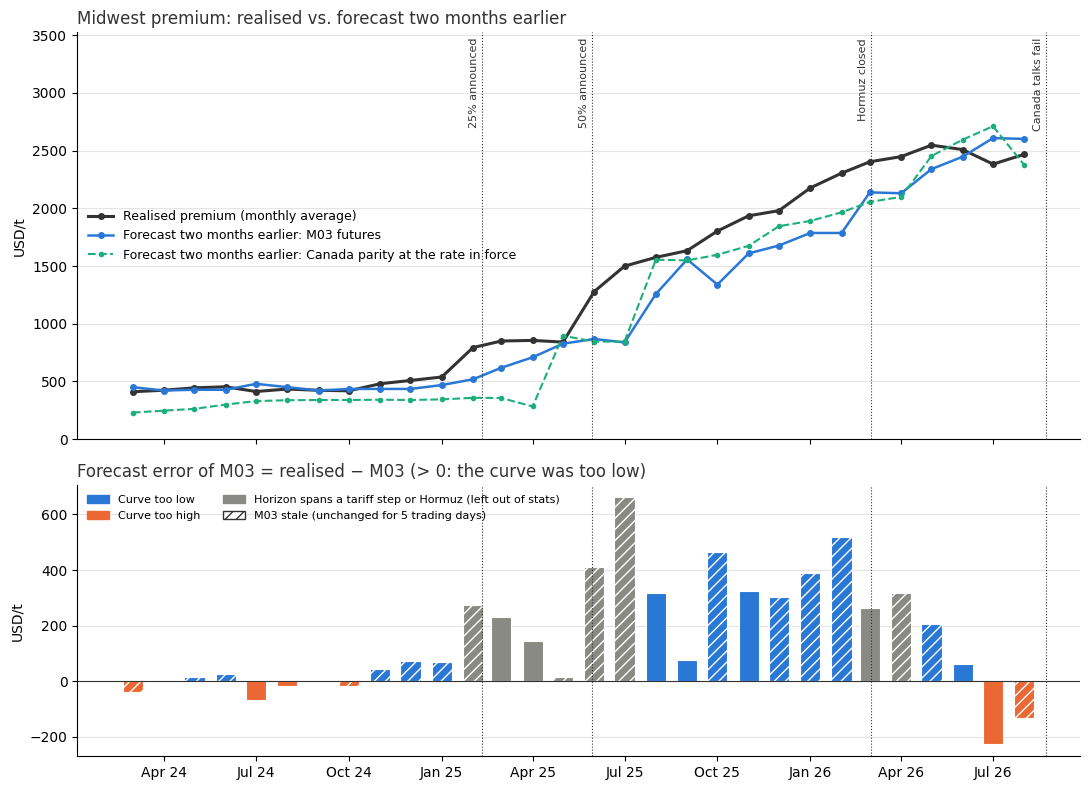

,forecasts,"mean error, M03 ($/t)",share with error > 0,fresh M03 forecasts,"mean error, fresh M03 only",RMSE: M03,RMSE: no change,RMSE: Canada parity,forecasts with parity
Pre-tariff (Canada 0%),69.0,13.04,0.51,31.0,2.94,88.47,85.74,239.26,41.0
"50%, before Hormuz",7.0,341.85,1.00,3.0,239.84,366.38,251.79,217.89,7.0
50% + Hormuz,4.0,-22.57,0.50,2.0,-82.07,169.94,115.14,182.16,4.0


In [16]:
# Forecast test on the month-end curve. At month-end t:
#   futures forecast:  M03, the contract for month t+2 (no days fixed yet)
#   no-change:         this month's realised premium
#   Canada parity:     (DP − F_netback) + F_mw + t × (LME 3M + DP − F_netback), using the statutory rate in force on the
#                      trade date (no look-ahead to announced steps), this month's DP and mid freight
#   outcome:           realised premium for t+2 (USGS monthly average; month-end M01 after Jun 2026, as above)
# Forecasts whose two-month horizon spans a tariff step or the Hormuz closure stay in the chart but are left out of the
# window statistics.
import numpy as np
import statsmodels.api as sm
from matplotlib.patches import Patch

HORMUZ = pd.Timestamp("2026-03-02")   # Strait of Hormuz closed to commercial traffic

curve_all = mwp_futures.pivot(index="date", columns="tenor", values="premium_usd_t")
month_end = curve_all.groupby(curve_all.index.to_period("M")).tail(1)
# Stale flag: M03 settle unchanged over the last 5 trading days of the month (see the CME note above)
m03_moved = curve_all[3].diff().ne(0).rolling(5).max().astype(bool)
fc = pd.DataFrame({"trade_date": month_end.index, "m03": month_end[3].values,
                   "fresh": m03_moved.loc[month_end.index].values},
                  index=month_end.index.to_period("M").to_timestamp())
fc["target"] = fc.index + pd.DateOffset(months=2)
fc["now"] = mwp_all.reindex(fc.index).values
fc["realised"] = mwp_all.reindex(fc["target"]).values

def rate_on(day, origin):
    # Statutory rate in force on a given day
    return max([rate for start, rate in TARIFF_STEPS[origin] if pd.Timestamp(start) <= day], default=0.0)

f_net, f_mw = FREIGHT["ca_rtm"][mid], FREIGHT["ca_mw"][mid]
fc["t_ca"] = [rate_on(day, "Canada") for day in fc["trade_date"]]
fc["lme3m"] = lme3m_me.reindex(fc.index).values
fc["dp"] = dp_m.reindex(fc.index).values
fc["parity"] = (fc["dp"] - f_net) + f_mw + fc["t_ca"] * (fc["lme3m"] + fc["dp"] - f_net)   # NaN before Jul 2021 (no DP)
fc = fc.dropna(subset=["m03", "realised"])
fc["err_fut"] = fc["realised"] - fc["m03"]            # > 0: the curve was too low
fc["err_nochange"] = fc["realised"] - fc["now"]
fc["err_parity"] = fc["realised"] - fc["parity"]

def forecast_window(t):
    target = t + pd.DateOffset(months=2)
    if target <= pd.Timestamp("2025-01-01"):                                  # before the 10 Feb 25 announcement
        return "Pre-tariff (Canada 0%)"
    if t >= pd.Timestamp("2025-06-01") and target < pd.Timestamp("2026-03-01"):
        return "50%, before Hormuz"
    if t >= pd.Timestamp("2026-03-01"):
        return "50% + Hormuz"
    return "Spans an event"
fc["window"] = [forecast_window(t) for t in fc.index]

def rmse(e):
    return np.sqrt((e.dropna() ** 2).mean())

stats = {}
for w, s in fc[fc["window"] != "Spans an event"].groupby("window", sort=False):
    stats[w] = {"forecasts": len(s),
                "mean error, M03 ($/t)": s["err_fut"].mean(),
                "share with error > 0": (s["err_fut"] > 0).mean(),
                "fresh M03 forecasts": int(s["fresh"].sum()),
                "mean error, fresh M03 only": s.loc[s["fresh"], "err_fut"].mean(),
                "RMSE: M03": rmse(s["err_fut"]),
                "RMSE: no change": rmse(s["err_nochange"]),
                "RMSE: Canada parity": rmse(s["err_parity"]),
                "forecasts with parity": int(s["err_parity"].notna().sum())}
forecast_stats = pd.DataFrame(stats).T

# Chart: forecasts plotted at the month they forecast
pf = fc.loc["2024-01-01":]
x = pf["target"]
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True,
                               gridspec_kw={"height_ratios": [3, 2]})
ax1.plot(x, pf["realised"], color=INK, lw=2.2, marker="o", ms=4, label="Realised premium (monthly average)")
ax1.plot(x, pf["m03"], color=BLUE, lw=1.8, marker="o", ms=4, label="Forecast two months earlier: M03 futures")
ax1.plot(x, pf["parity"], color=GREEN, lw=1.5, ls="--", marker="o", ms=3,
         label="Forecast two months earlier: Canada parity at the rate in force")
ax1.set_ylabel("USD/t")
ax1.set_title("Midwest premium: realised vs. forecast two months earlier", loc="left", color=INK)
ax1.set_ylim(0, pf[["realised", "m03", "parity"]].max().max() * 1.3)   # headroom for the event labels
ax1.legend(loc="center left", frameon=False, fontsize=9)

excluded = pf["window"] == "Spans an event"
bar_colors = [MUTED if ex else (BLUE if e >= 0 else ORANGE) for e, ex in zip(pf["err_fut"], excluded)]
bars = ax2.bar(x, pf["err_fut"], width=20, color=bar_colors, edgecolor="white", linewidth=0.8)
for bar, fresh in zip(bars, pf["fresh"]):
    if not fresh:
        bar.set_hatch("///")
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("USD/t")
ax2.set_title("Forecast error of M03 = realised − M03 (> 0: the curve was too low)", loc="left", color=INK)
ax2.legend(handles=[Patch(color=BLUE, label="Curve too low"), Patch(color=ORANGE, label="Curve too high"),
                    Patch(color=MUTED, label="Horizon spans a tariff step or Hormuz (left out of stats)"),
                    Patch(facecolor="white", edgecolor=INK, hatch="///", label="M03 stale (unchanged for 5 trading days)")],
           loc="upper left", frameon=False, fontsize=8, ncol=2)

events = {pd.Timestamp("2025-02-10"): "25% announced", pd.Timestamp("2025-05-30"): "50% announced",
          HORMUZ: "Hormuz closed", pd.Timestamp("2026-08-22"): "Canada talks fail"}
for ax in (ax1, ax2):
    for d0 in events:
        ax.axvline(d0, color=INK, lw=0.8, ls=":")
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d0, label in events.items():
    ax1.annotate(label, xy=(d0, ax1.get_ylim()[1]), xytext=(-2, -4), textcoords="offset points",
                 fontsize=8, color=INK, rotation=90, va="top", ha="right")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
fig.tight_layout()
plt.show()

display(forecast_stats.round(2))

Takeaway:
- **Before the tariff, the curve was a fair forecast.** Over 69 forecasts the mean error was +13 \$/t, small next to a typical miss of 88 \$/t (RMSE), and M03 did about as well as no change (RMSE 88 vs 86). Canada parity is no benchmark here, since Canada was not the price-setter before Mar 2025 (cell 10).
- **Under 50%, before Hormuz, it was too low every time.** All 7 forecasts (made Jun–Dec 2025, for Aug 25–Feb 26) came in below the outcome, by 342 \$/t on average. The curve did worse than both benchmarks: RMSE 366, against 252 for no change and 218 for Canada parity. The market kept pricing relief while the premium tracked parity upwards as LME and DP rose.
- **Stale quotes make the miss bigger but don't explain it.** Four of the seven M03 quotes were stale; the three fresh ones still missed by +240 \$/t.
- **Since Hormuz, no bias:** −23 \$/t over 4 forecasts. The curve was too high for Jul and Aug 26.
- **How sure:** 7 forecasts that overlap by a month, all from one regime. The direction is clear (7 of 7 too low, by far more than the usual miss), but it is one episode, not a pattern.
- **Reading:** two explanations fit, and both can hold at once. (1) A peso problem: the curve fairly priced a chance of relief that didn't come in this sample. (2) A risk premium: producers and importers selling the curve to lock in a premium that a deal could wipe out, while consumers mostly pass the premium on and hedge less, push M03 below the expected premium, so longs are paid to take the other side. The evidence leans to (1) for most of the miss: the curve repriced on relief news (the CME Oct-26 contract fell 298 \$/t, 13%, on the 20 Aug 26 Canada headlines and regained it when talks collapsed), and 342 \$/t on a curve near 1,570 \$/t is a ~22% two-month return, too large to be compensation for risk alone. Telling them apart needs more episodes, hedger positioning (CFTC COT on CME AUP), or the implied-probability model in `plan.md`. Cells 28–30 check the miss against the LME and Rotterdam markets over the same months.

### Control: did the LME and Rotterdam futures miss too?

If the MW curve was too low only because aluminium and European premiums rallied more than anyone expected, the LME futures should show the same miss over the same months, and Canada parity should account for the MW miss: under 50%, a surprise of ΔLME in the metal and ΔDP in Rotterdam moves the premium by t × ΔLME + (1 + t) × ΔDP. Whatever is left is US-specific, which is where priced-in relief would show up.

Data limit: the repo has no futures history for Rotterdam. The LME ED workbook holds monthly final settlements only, the DUP file is the spot assessment, and the one CME DP contract (Oct-26) has not settled. So DP is measured against no change, which makes its row a surprise, not a futures error.

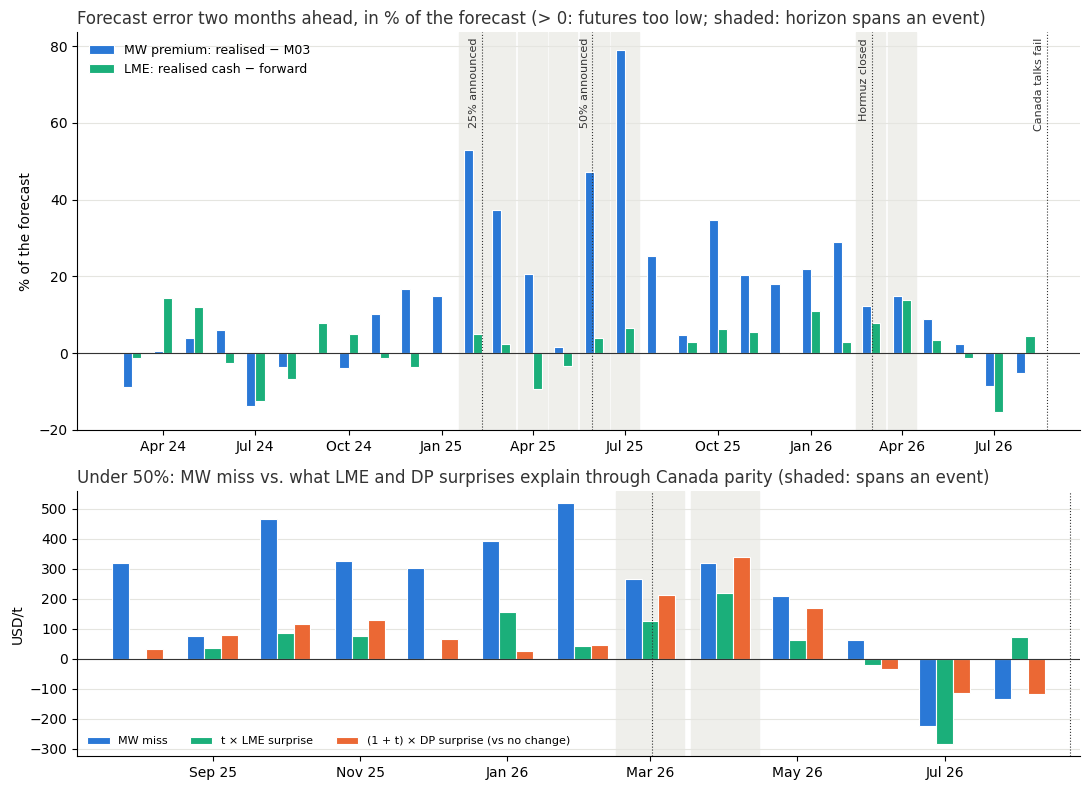

,forecasts,MW: mean error ($/t),MW: share too low,MW: mean error / pre-tariff RMSE,LME: mean error ($/t),LME: share too low,LME: mean error / pre-tariff RMSE,LME: RMSE futures,LME: RMSE no change,DP: mean surprise ($/t),DP: share rising,DP forecasts,MW miss from t × LME surprise,MW miss from (1+t) × DP surprise,MW miss left unexplained
Pre-tariff (Canada 0%),69.0,13.04,0.51,0.15,-0.20,0.51,-0.00,195.94,195.03,0.62,0.33,41.0,NaN,NaN,NaN
"50%, before Hormuz",7.0,341.85,1.00,3.86,111.39,0.86,0.57,150.79,155.86,46.45,1.00,7.0,55.69,69.67,216.48
50% + Hormuz,4.0,-22.57,0.50,-0.26,-87.71,0.50,-0.45,301.57,319.73,-16.56,0.25,4.0,-43.85,-24.84,46.13


,trade_date,err_fut,err_lme,mw_from_lme,dp_surprise,mw_from_dp,mw_unexplained,window
date,,,,,,,,
2025-06-01,2025-06-30,318.0,2.0,1.0,20.0,31.0,287.0,"50%, before Hormuz"
2025-07-01,2025-07-31,75.0,72.0,36.0,52.0,79.0,-40.0,"50%, before Hormuz"
2025-08-01,2025-08-29,464.0,168.0,84.0,76.0,115.0,265.0,"50%, before Hormuz"
2025-09-01,2025-09-30,326.0,150.0,75.0,85.0,128.0,123.0,"50%, before Hormuz"
2025-10-01,2025-10-31,302.0,-8.0,-4.0,44.0,66.0,240.0,"50%, before Hormuz"
2025-11-01,2025-11-28,390.0,309.0,155.0,16.0,24.0,212.0,"50%, before Hormuz"
2025-12-01,2025-12-31,518.0,86.0,43.0,31.0,46.0,429.0,"50%, before Hormuz"
2026-01-01,2026-01-30,265.0,248.0,124.0,141.0,211.0,-70.0,Spans an event
2026-02-01,2026-02-27,317.0,439.0,220.0,225.0,338.0,-240.0,Spans an event


In [ ]:
# Control for the forecast test: were the LME futures and Rotterdam premium also too low over the same months?
# Same month-end trade dates, targets and windows as the cell above.
#   LME forecast:  forward for the middle of month t+2 (~1.5 months out), interpolated linearly between cash and 3M on
#                  the trade date. The cash–3M spread is tens of $/t, so the interpolation error is small next to the
#                  misses. Outcome: the average LME cash price of month t+2 (as the MW contract settles on a monthly average).
#   Rotterdam DP:  there is no futures history for DP or DUP in the repo (the LME ED file holds monthly final settlements
#                  only; the one CME DP contract, Oct-26, has not settled). So DP gets the no-change forecast: DP(t+2) − DP(t)
#                  is the surprise, not a futures error. DUP after Oct 2025 is reconstructed from DP, so it adds nothing.
# If the MW miss were just metal and European premiums rallying more than expected, Canada parity says how much of it
# that would explain: ΔMWP = t × ΔLME + (1 + t) × ΔDP (cell 26 formula, freight fixed), with t = 50% under the 50% regime.
lme_d = lme.set_index("date")
cash_te = lme_d["cash"].reindex(fc["trade_date"]).values
m3_te = lme_d["three_month"].reindex(fc["trade_date"]).values
fc["lme_fwd"] = cash_te + (m3_te - cash_te) * 1.5 / 3
fc["lme_realised"] = lme_m.reindex(fc["target"]).values
fc["err_lme"] = fc["lme_realised"] - fc["lme_fwd"]         # > 0: LME futures too low
fc["err_lme_nochange"] = fc["lme_realised"] - cash_te
fc["dp_surprise"] = dp_m.reindex(fc["target"]).values - dp_m.reindex(fc.index).values
fc["mw_from_lme"] = fc["t_ca"] * fc["err_lme"]
fc["mw_from_dp"] = (1 + fc["t_ca"]) * fc["dp_surprise"]
fc["mw_unexplained"] = fc["err_fut"] - fc["mw_from_lme"] - fc["mw_from_dp"]

pre = fc[fc["window"] == "Pre-tariff (Canada 0%)"]
usual_mw, usual_lme = rmse(pre["err_fut"]), rmse(pre["err_lme"])   # the usual size of a miss, before the tariff
control = {}
for w, s in fc[fc["window"] != "Spans an event"].groupby("window", sort=False):
    row = {"forecasts": len(s),
           "MW: mean error ($/t)": s["err_fut"].mean(),
           "MW: share too low": (s["err_fut"] > 0).mean(),
           "MW: mean error / pre-tariff RMSE": s["err_fut"].mean() / usual_mw,
           "LME: mean error ($/t)": s["err_lme"].mean(),
           "LME: share too low": (s["err_lme"] > 0).mean(),
           "LME: mean error / pre-tariff RMSE": s["err_lme"].mean() / usual_lme,
           "LME: RMSE futures": rmse(s["err_lme"]),
           "LME: RMSE no change": rmse(s["err_lme_nochange"]),
           "DP: mean surprise ($/t)": s["dp_surprise"].mean(),
           "DP: share rising": (s["dp_surprise"] > 0).mean(),
           "DP forecasts": int(s["dp_surprise"].notna().sum())}
    if w != "Pre-tariff (Canada 0%)":   # the parity split only applies once Canada sets the price (cell 10)
        row |= {"MW miss from t × LME surprise": s["mw_from_lme"].mean(),
                "MW miss from (1+t) × DP surprise": s["mw_from_dp"].mean(),
                "MW miss left unexplained": s["mw_unexplained"].mean()}
    control[w] = row
control_stats = pd.DataFrame(control).T

# Chart. Top: errors in % of the forecast, so a 2,700 $/t metal price and a 1,500 $/t premium share one axis.
# Bottom: under 50%, the MW miss next to what the LME and DP surprises would explain through Canada parity.
pf = fc.loc["2024-01-01":]
x = pf["target"]
w_days = pd.Timedelta(days=9)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), gridspec_kw={"height_ratios": [3, 2]})
ax1.bar(x - w_days / 2, 100 * pf["err_fut"] / pf["m03"], width=9, color=BLUE, edgecolor="white", linewidth=0.8,
        label="MW premium: realised − M03")
ax1.bar(x + w_days / 2, 100 * pf["err_lme"] / pf["lme_fwd"], width=9, color=GREEN, edgecolor="white", linewidth=0.8,
        label="LME: realised cash − forward")
ax1.axhline(0, color=INK, lw=0.8)
ax1.set_ylabel("% of the forecast")
ax1.set_title("Forecast error two months ahead, in % of the forecast (> 0: futures too low; shaded: horizon spans an event)",
              loc="left", color=INK)
ax1.legend(loc="upper left", frameon=False, fontsize=9)

p50 = pf[(pf["trade_date"] >= TARIFF_DATE) & pf["dp_surprise"].notna()]
x50 = p50["target"]
w3 = pd.Timedelta(days=7)
ax2.bar(x50 - w3, p50["err_fut"], width=7, color=BLUE, edgecolor="white", linewidth=0.8, label="MW miss")
ax2.bar(x50, p50["mw_from_lme"], width=7, color=GREEN, edgecolor="white", linewidth=0.8, label="t × LME surprise")
ax2.bar(x50 + w3, p50["mw_from_dp"], width=7, color=ORANGE, edgecolor="white", linewidth=0.8,
        label="(1 + t) × DP surprise (vs no change)")
ax2.axhline(0, color=INK, lw=0.8)
ax2.set_ylabel("USD/t")
ax2.set_title("Under 50%: MW miss vs. what LME and DP surprises explain through Canada parity (shaded: spans an event)", loc="left", color=INK)
ax2.legend(loc="lower left", frameon=False, fontsize=8, ncol=3)

ax2.set_xlim(x50.min() - pd.Timedelta(days=25), x50.max() + pd.Timedelta(days=25))
for ax, frame in ((ax1, pf), (ax2, p50)):
    for d in frame.loc[frame["window"] == "Spans an event", "target"]:
        ax.axvspan(d - pd.Timedelta(days=14), d + pd.Timedelta(days=14), color="#efefeb", zorder=0)
    for d0 in events:
        if ax.get_xlim()[0] <= mdates.date2num(d0) <= ax.get_xlim()[1]:
            ax.axvline(d0, color=INK, lw=0.8, ls=":")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %y"))
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
for d0, label in events.items():
    ax1.annotate(label, xy=(d0, ax1.get_ylim()[1]), xytext=(-2, -4), textcoords="offset points",
                 fontsize=8, color=INK, rotation=90, va="top", ha="right")
fig.tight_layout()
plt.show()

display(control_stats.round(2))
display(p50[["trade_date", "err_fut", "err_lme", "mw_from_lme", "dp_surprise", "mw_from_dp", "mw_unexplained", "window"]]
        .round(0))

Takeaway:
- **LME futures were a fair forecast before the tariff:** mean error −0 \$/t over the same 69 forecasts, and RMSE equal to no change (196 vs 195).
- **Under 50%, before Hormuz, the LME futures were also too low**: 6 of 7 forecasts, by +111 \$/t on average, as the metal climbed from ~2,600 to ~3,150 \$/t. But that is 0.6 of the usual LME miss (196 \$/t), against 3.9 usual misses for the MW curve (342 vs 88). In % of the forecast, LME missed by ~4% and the MW curve by ~22%. The MW miss is not a general bias in aluminium futures.
- **Rotterdam DP rose in all 7 windows,** by 46 \$/t over two months on average (189 \$/t in Jun 25, 361 by Feb 26). With no DP futures history, it's unclear whether the DP curve saw that rise coming.
- **Through Canada parity, the LME and DP surprises explain about a third of the MW miss:** 56 \$/t from t × LME and 70 from (1 + t) × DP, leaving **~217 \$/t (63%) US-specific**. That residual is still 2.5× the usual MW miss, so the peso-problem / risk-premium reading of cell 27 survives the control.
- **The split behaves where it should.** The two forecasts whose horizon spans the Hormuz closure (made Jan and Feb 26) missed by +265 and +317 \$/t, and the LME and DP jumps explain all of it (residuals −70 and −240). A common shock shows up as explained, not as residual. Since Hormuz the residual is +46 \$/t over 4 forecasts, so no clear bias.
- **How sure:** 7 overlapping forecasts from one rally. The DP part is measured against no change: if a DP curve had priced part of the rise, more of the MW miss would be US-specific; if it had priced a fall, less. One data point to come: the CME Oct-26 DP contract was 467 \$/t on 31 Aug and 557 on 8 Oct (with about a quarter of October fixed); it settles at the end of October. A proper DP test needs the LME ED daily closing prices (the counterpart of the MW `UP` workbook) or more CME IED contracts.
- **So what for a hedger:** most of what a short MW futures position lost under 50% came from US policy expectations, not from the metal or Europe. An LME overlay at ~t, or a Rotterdam position, would have offset only about a third of it, which fits the risk section: premium positions carry ~t of LME, but tariff news can't be hedged outside the US contract.

## Risk: the tariff couples the premium to LME

**Before the tariff, LME and the Midwest premium were linked only through common causes.** Global supply and demand moves LME, the European premium and US supply and demand, and the premium follows the last two. So a premium position carried some LME exposure, but only as a statistical relation that has to be estimated.

**An ad valorem tariff adds a direct link.** The pass-through section showed that the premium sits at Canada import parity:

MWP = (DP − F_netback) + F_mw + t × (LME + DP − F_netback)

The duty is charged on the metal's value, and the value contains LME, so **∂MWP/∂LME = t**. At 50%, each 100 \$/t on LME adds 50 \$/t to the duty and so to the premium. This link doesn't need estimating: the tariff rule sets it, and it holds as long as the US imports at the margin.

**Predictions:**
1. **The premium's LME beta rises by about t.** At 50% it should land between 0.5 (the duty link alone) and about 0.7 (the duty link plus the pre-tariff indirect channel).
2. **The rise is US-specific.** The Rotterdam duty-paid premium (DP) is priced off the same global market but faces no US tariff, so its LME beta should not change. If both rise, a tight market is driving it, not the tariff.
3. **Futures carry the same link,** scaled by the tariff the market expects for the delivery month. A fixed MW contract should move by about t per \$/t of LME.

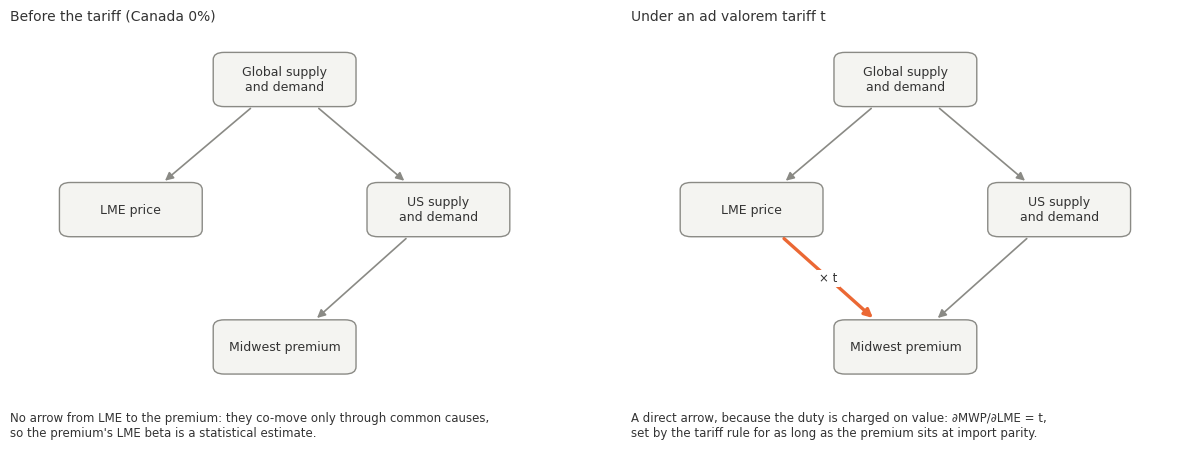

In [17]:
# The causal picture behind the hedge, simplified for illustration. An arrow is a causal link. The European premium,
# which enters the parity condition, is folded into the global -> US supply and demand path.
from matplotlib.patches import FancyBboxPatch

NODES = {"global": (0.50, 0.86, "Global supply\nand demand"),
         "lme":    (0.22, 0.50, "LME price"),
         "us":     (0.78, 0.50, "US supply\nand demand"),
         "mwp":    (0.50, 0.12, "Midwest premium")}
BOX_W, BOX_H = 0.26, 0.15   # axes fraction

def box_edge(p, q):
    """Point where the line from box centre p towards q leaves the box."""
    dx, dy = q[0] - p[0], q[1] - p[1]
    s = min(BOX_W / 2 / abs(dx) if dx else np.inf, BOX_H / 2 / abs(dy) if dy else np.inf)
    return p[0] + s * dx, p[1] + s * dy

def draw_dag(ax, edges, title, caption):
    for x, y, label in NODES.values():
        ax.add_patch(FancyBboxPatch((x - BOX_W / 2, y - BOX_H / 2), BOX_W, BOX_H, boxstyle="round,pad=0,rounding_size=0.02",
                                    fc="#f4f4f1", ec=MUTED, lw=1))
        ax.text(x, y, label, ha="center", va="center", fontsize=9, color=INK)
    for a, b, label, color, lw in edges:
        p, q = NODES[a][:2], NODES[b][:2]
        start, end = box_edge(p, q), box_edge(q, p)
        ax.annotate("", xy=end, xytext=start, arrowprops=dict(arrowstyle="-|>", color=color, lw=lw, mutation_scale=12))
        if label:
            ax.text((start[0] + end[0]) / 2, (start[1] + end[1]) / 2, label, ha="center", va="center", fontsize=8.5,
                    color=INK, bbox=dict(fc="white", ec="none", pad=1.5))
    ax.set_title(title, loc="left", color=INK, fontsize=10)
    ax.text(0.0, -0.06, caption, ha="left", va="top", fontsize=8.5, color=INK, transform=ax.transAxes)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis("off")

COMMON = [("global", "lme", None, MUTED, 1.2), ("global", "us", None, MUTED, 1.2), ("us", "mwp", None, MUTED, 1.2)]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.6))
draw_dag(ax1, COMMON,
         "Before the tariff (Canada 0%)",
         "No arrow from LME to the premium: they co-move only through common causes,\n"
         "so the premium's LME beta is a statistical estimate.")
draw_dag(ax2, COMMON + [("lme", "mwp", "× t", ORANGE, 2.4)],
         "Under an ad valorem tariff t",
         "A direct arrow, because the duty is charged on value: ∂MWP/∂LME = t,\n"
         "set by the tariff rule for as long as the premium sits at import parity.")
fig.tight_layout()
plt.show()

In [18]:
# Evidence 1, monthly spot: the premium's LME beta, i.e. the slope of Δ MW premium (monthly average) on Δ LME cash (monthly
# average), by regime. Rotterdam DP is the control: it is priced off the same global market but faces no US tariff, so a
# tight-market story raises both betas, while the tariff raises only the MW one (prediction 2).
# Months whose change spans a tariff announcement or step (Feb–Apr and Jun–Jul 2025) are left out: the premium's jump in
# those months is the tariff level changing, not an LME shock.
def hac_ols(y, X, lags):
    return sm.OLS(y, sm.add_constant(X), missing="drop").fit(cov_type="HAC", cov_kwds={"maxlags": lags})

STEP_MONTHS = pd.to_datetime(["2025-02-01", "2025-03-01", "2025-04-01", "2025-06-01", "2025-07-01"])
dmo = pd.concat([lme_m, dp_m, mwp_all], axis=1).diff().drop(STEP_MONTHS)
dmo["t_ca"] = [tariff_rate(d, "Canada") for d in dmo.index]

REGIMES_B = {"Pre-tariff (Canada 0%)": ("2021-08-01", "2025-01-01"),   # DP starts Jul 2021
             "50%, before Hormuz":     ("2025-08-01", "2026-02-01"),
             "50% + Hormuz":           ("2026-03-01", "2026-08-01")}
beta_m = {}
for k, (a, b) in REGIMES_B.items():
    s = dmo.loc[a:b]
    mw, eu = hac_ols(s["mwp"], s["lme"], 1), hac_ols(s["dp"], s["lme"], 1)
    beta_m[k] = {"months": len(s), "t": s["t_ca"].mean(),
                 "β MW premium": mw.params["lme"], "s.e. (MW)": mw.bse["lme"],
                 "β Rotterdam DP": eu.params["lme"], "s.e. (DP)": eu.bse["lme"]}
beta_m = pd.DataFrame(beta_m).T
BETA_PRE = beta_m.loc["Pre-tariff (Canada 0%)", "β MW premium"]   # the indirect channel before the tariff
beta_m["theory, MW"] = [f"{t:.2f} to {t + BETA_PRE:.2f}" if t else "—" for t in beta_m["t"]]

# Pooled over all months: Δ MWP = a + b × ΔLME + c × (t × ΔLME). The duty link predicts c = 1 (each point of tariff adds a
# point of LME beta); b is the indirect channel. The second version also holds the European premium fixed.
pool = dmo.loc["2021-08-01":"2026-08-01"].dropna()
X = pd.DataFrame({"ΔLME": pool["lme"], "t × ΔLME": pool["t_ca"] * pool["lme"]})
pooled_fits = {f"LME only ({len(pool)} months)": hac_ols(pool["mwp"], X, 2),
               f"with ΔDP ({len(pool)} months)": hac_ols(pool["mwp"], X.assign(ΔDP=pool["dp"]), 2)}
pooled_b = pd.concat({k: pd.DataFrame({"coef": f.params, "s.e.": f.bse}).drop("const") for k, f in pooled_fits.items()},
                     axis=1)

display(beta_m.round(2))
display(pooled_b.round(3))

,months,t,β MW premium,s.e. (MW),β Rotterdam DP,s.e. (DP),"theory, MW"
Pre-tariff (Canada 0%),42.0,0.0,0.19,0.05,0.10,0.05,—
"50%, before Hormuz",7.0,0.5,0.30,0.11,-0.00,0.03,0.50 to 0.69
50% + Hormuz,6.0,0.5,0.33,0.06,0.26,0.06,0.50 to 0.69


LME only (56 months)        with ΔDP (56 months)      
                         coef   s.e.                 coef  s.e.
ΔLME                    0.190  0.050                0.132  0.04
t × ΔLME                0.464  0.202                0.325  0.24
ΔDP                       NaN    NaN                0.584  0.14

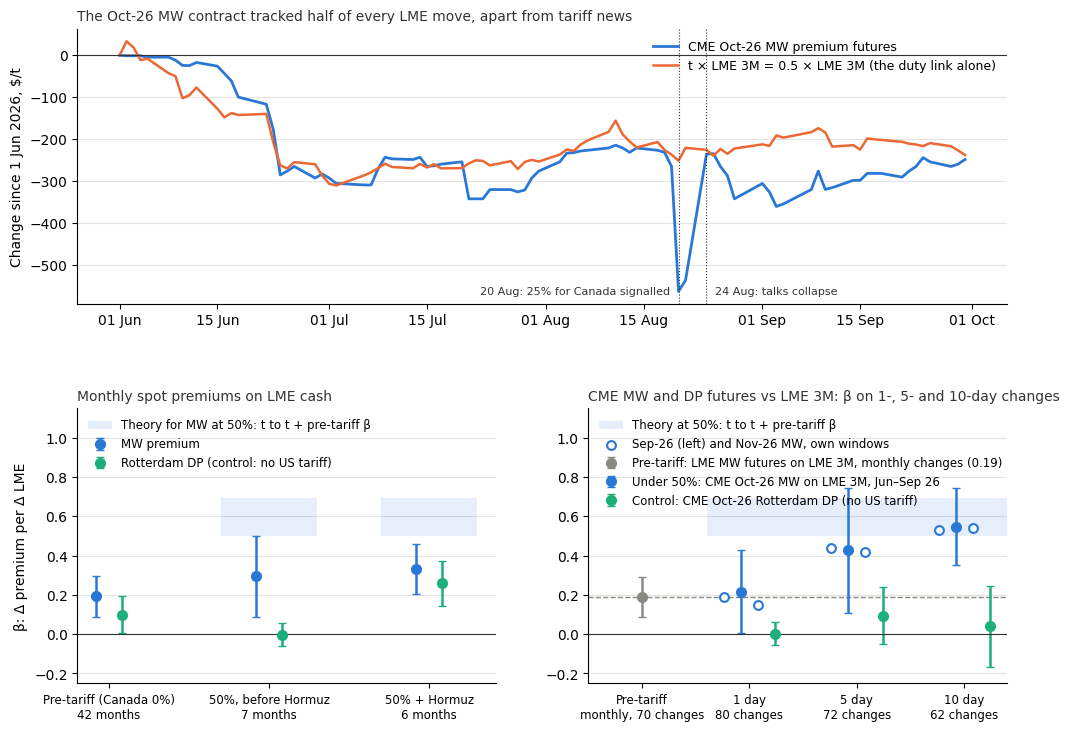

changes     β  s.e.    R²  \
window                 change over                              
Jun–Sep 26             1 day           80.0  0.22  0.11  0.11   
                       5 day           72.0  0.43  0.16  0.36   
                       10 day          62.0  0.55  0.10  0.65   
Mar–Sep 26 (thinner)   1 day          141.0  0.16  0.05  0.11   
                       5 day          133.0  0.34  0.09  0.37   
                       10 day         123.0  0.45  0.11  0.56   
DP control, Jun–Sep 26 1 day           70.0  0.00  0.03  0.00   
                       5 day           62.0  0.09  0.07  0.10   
                       10 day          52.0  0.04  0.11  0.02   

                                    premium risk ($/t)  \
window                 change over                       
Jun–Sep 26             1 day                     24.52   
                       5 day                     67.76   
                       10 day                   109.51   
Mar–Sep 26 (thinner)   1 day                     24.40   
                       5 day                     61.84   
                       10 day                    94.10   
DP control, Jun–Sep 26 1 day                     11.71   
                       5 day                     26.02   
                       10 day                    37.32   

                                    with t × LME overlay ($/t)  
window                 change over                              
Jun–Sep 26             1 day                             25.52  
                       5 day                             54.51  
                       10 day                            64.95  
Mar–Sep 26 (thinner)   1 day                             28.70  
                       5 day                             52.05  
                       10 day                            63.06  
DP control, Jun–Sep 26 1 day                             20.64  
                       5 day                             43.37  
                       10 day                            65.55

,window,β 1 day,s.e. 1 day,β 5 day,s.e. 5 day,β 10 day,s.e. 10 day,10-day changes
CME Sep 26 MW,16 Apr – 31 Aug,0.19,0.08,0.44,0.14,0.53,0.1,76
CME Oct 26 MW,01 Jun – 30 Sep,0.22,0.11,0.43,0.16,0.55,0.1,62
CME Nov 26 MW,01 Jun – 08 Oct,0.15,0.11,0.42,0.15,0.54,0.1,68


Pre-tariff baseline, LME MW futures (monthly, 70 changes): β = 0.19 (s.e. 0.05), R² = 0.22


,changes,β MW,β DP,β MW − DP,s.e. (MW − DP)
1 day,70.0,0.29,0.00,0.29,0.13
5 day,62.0,0.55,0.09,0.45,0.13
10 day,52.0,0.62,0.04,0.58,0.09


DP control: 46% of settlements unchanged, 15 Jun – 30 Sep (MW: 12%); daily s.d. 11.7 $/t
DP on the US tariff-news days ($/t): 20 Aug +35.0, 21 Aug +10.6, 24 Aug -11.3


In [20]:
# Evidence 2, futures: the CME Oct-26 MW contract (AUP; scripts/clean_comex.py) against LME 3M, daily settlements.
# Window 1 Jun – 30 Sep 2026. From June the contract trades on most days (12% of settlements unchanged, against 60–90% in
# 2025). In October it enters its averaging month, so part of it is fixed and its LME delta shrinks.
# Theory (prediction 3): the contract moves by E[t for Oct 26] × ΔLME, plus any surviving indirect channel (BETA_PRE).
# Without the tariff link it would sit at the pre-tariff futures beta, measured below on the LME's MW contract.
# Policy days are left out: 20 Aug (US signals 25% for Canada: Oct-26 −298 $/t), 21 Aug, and 24 Aug (talks collapse: +301).
# They move the expected tariff, not LME, and on their own would swamp 80 days of LME-driven moves.
# The thin contract's settlements catch up with LME over a few days, so betas are shown on 1-, 5- and 10-day changes
# (overlapping, HAC errors with h lags; 10-day changes give only ~8 independent windows).
# Control: the CME Oct-26 Rotterdam duty-paid contract (EDP), same regression and policy days. It is priced off the same
# global market and settles in the same month but faces no US tariff, so it should sit near its pre-tariff monthly beta
# (0.10 in Evidence 1), plus at most the EU's 3% duty on value. If it also moved ~0.5 with LME, a tight market would
# explain the MW beta, not the tariff (prediction 2). Its history starts 15 Jun 2026.
CME_MW = Path.cwd() / "data" / "midwest_premium_cme.csv"
cme = pd.read_csv(CME_MW, parse_dates=["date", "contract_month"])
oct26 = cme[cme["contract_month"] == "2026-10-01"].set_index("date")["premium_usd_t"]
px = pd.concat([oct26.rename("fut"), lme.set_index("date")["three_month"].rename("lme3m")], axis=1, join="inner")
CME_DP = Path.cwd() / "data" / "europe_duty_paid_premium_cme.csv"
cme_dp = pd.read_csv(CME_DP, parse_dates=["date", "contract_month"])
oct26_dp = cme_dp[cme_dp["contract_month"] == "2026-10-01"].set_index("date")["premium_usd_t"]
px_dp = pd.concat([oct26_dp.rename("fut"), lme.set_index("date")["three_month"].rename("lme3m")], axis=1, join="inner")

CME_WINDOW = ("2026-06-01", "2026-09-30")
POLICY_DAYS = pd.to_datetime(["2026-08-20", "2026-08-21", "2026-08-24"])
HORIZONS_D = (1, 5, 10)
T_NOW = 0.5

def cme_beta(a, b, h, data=px):
    x = data.loc[a:b]
    ch = (x - x.shift(h)).dropna()
    hit = pd.Series(x.index.isin(POLICY_DAYS), index=x.index).rolling(h, min_periods=1).max().astype(bool)
    ch = ch[~hit.reindex(ch.index)]   # drop every h-day change whose window contains a policy day
    fit = hac_ols(ch["fut"], ch["lme3m"], h)
    return {"changes": len(ch), "β": fit.params["lme3m"], "s.e.": fit.bse["lme3m"], "R²": fit.rsquared,
            "premium risk ($/t)": ch["fut"].std(),
            "with t × LME overlay ($/t)": (ch["fut"] - T_NOW * ch["lme3m"]).std()}   # overlay set by the rule, not fitted

cme_tbl = pd.DataFrame({(w, f"{h} day"): cme_beta(a, b, h, data)
                        for w, (a, b, data) in {"Jun–Sep 26": (*CME_WINDOW, px),
                                                "Mar–Sep 26 (thinner)": ("2026-03-01", "2026-09-30", px),
                                                "DP control, Jun–Sep 26": (*CME_WINDOW, px_dp)}.items()
                        for h in HORIZONS_D}).T
cme_tbl.index.names = ["window", "change over"]

# Across contracts: the same regression on the Sep-26 and Nov-26 MW contracts, each over its own liquid window (from when
# it trades on most days to the end of the month before its averaging month; Nov-26 runs to the end of the data).
# The three contracts share dates and LME moves, so they are not independent tests. They check that the link is not a
# quirk of one contract, and Sep-26 adds 16 Apr – 31 May 2026.
cme_by = cme.pivot_table(index="date", columns="contract_month", values="premium_usd_t")
lme3m_d = lme.set_index("date")["three_month"].rename("lme3m")
CONTRACT_WINDOWS = {"Sep 26": ("2026-04-16", "2026-08-31"), "Oct 26": CME_WINDOW, "Nov 26": ("2026-06-01", "2026-10-08")}
across = {}
for name, (a, b) in CONTRACT_WINDOWS.items():
    data = pd.concat([cme_by[pd.to_datetime(name, format="%b %y")].rename("fut"), lme3m_d], axis=1, join="inner").dropna()
    row = {"window": f"{pd.Timestamp(a):%d %b} – {pd.Timestamp(b):%d %b}"}
    for h in HORIZONS_D:
        res = cme_beta(a, b, h, data)
        row.update({f"β {h} day": round(res["β"], 2), f"s.e. {h} day": round(res["s.e."], 2)})
    row["10-day changes"] = res["changes"]
    across[f"CME {name} MW"] = row
across_tbl = pd.DataFrame(across).T

# The control test proper: MW minus DP on the dates both trade (15 Jun – 30 Sep), regressed on LME 3M. The slope is
# β_MW − β_DP with a HAC error that allows for the two contracts' common shocks.
both = pd.concat({"mw": px["fut"], "dp": px_dp["fut"], "lme3m": px["lme3m"]}, axis=1, join="inner").loc[:CME_WINDOW[1]]

def mw_minus_dp(h):
    ch = (both - both.shift(h)).dropna()
    hit = pd.Series(both.index.isin(POLICY_DAYS), index=both.index).rolling(h, min_periods=1).max().astype(bool)
    ch = ch[~hit.reindex(ch.index)]
    fits = {k: hac_ols(y, ch["lme3m"], h) for k, y in {"MW": ch["mw"], "DP": ch["dp"], "MW − DP": ch["mw"] - ch["dp"]}.items()}
    return {"changes": len(ch), **{f"β {k}": f.params["lme3m"] for k, f in fits.items()},
            "s.e. (MW − DP)": fits["MW − DP"].bse["lme3m"]}

diff_tbl = pd.DataFrame({f"{h} day": mw_minus_dp(h) for h in HORIZONS_D}).T
dp_daily = px_dp["fut"].diff()
dp_policy = dp_daily.reindex(POLICY_DAYS)   # the control on the US tariff-news days

# Pre-tariff baseline for futures. The CME contract barely traded before 2025, so use the LME's own MW contract
# (midwest_premium_curve.csv): the change in a fixed contract (3 months after the start month, so none of it is fixed yet)
# from one month-end to the next, on the change in LME 3M. Monthly changes get round the stale daily settlements.
# Start months Mar 2019 – Dec 2024, so every change ends before the 10 Feb 2025 announcement.
l3m = lme.set_index("date")["three_month"]
month_ends = by_contract.index.to_series().groupby(by_contract.index.to_period("M")).last()
base = []
for p0, d0 in month_ends.loc[:"2024-12"].items():
    d1, cm = month_ends.get(p0 + 1), (p0 + 3).to_timestamp()
    if d1 is None or cm not in by_contract:
        continue
    base.append({"dfut": by_contract.loc[d1, cm] - by_contract.loc[d0, cm],
                 "dlme": l3m.loc[:d1].iloc[-1] - l3m.loc[:d0].iloc[-1]})
base = pd.DataFrame(base).dropna()
base_fit = hac_ols(base["dfut"], base["dlme"], 1)
BETA_FUT_PRE, SE_FUT_PRE = base_fit.params["dlme"], base_fit.bse["dlme"]

# Chart: what the coupling looks like (top), the monthly betas by regime (bottom left), the futures betas (bottom right)
fig = plt.figure(figsize=(12, 8.5))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1], hspace=0.38, wspace=0.22)
ax0 = fig.add_subplot(gs[0, :])
ax1 = fig.add_subplot(gs[1, 0])
ax2 = fig.add_subplot(gs[1, 1], sharey=ax1)

w = px.loc[CME_WINDOW[0]:CME_WINDOW[1]]
ax0.plot(w.index, w["fut"] - w["fut"].iloc[0], color=BLUE, lw=2, label="CME Oct-26 MW premium futures")
ax0.plot(w.index, T_NOW * (w["lme3m"] - w["lme3m"].iloc[0]), color=ORANGE, lw=1.8,
         label="t × LME 3M = 0.5 × LME 3M (the duty link alone)")
ax0.axhline(0, color=INK, lw=0.8)
low = (w["fut"] - w["fut"].iloc[0]).min()
for d0, label, dx, ha in [(POLICY_DAYS[0], "20 Aug: 25% for Canada signalled", -6, "right"),
                          (POLICY_DAYS[-1], "24 Aug: talks collapse", 6, "left")]:
    ax0.axvline(d0, color=INK, lw=0.8, ls=":")
    ax0.annotate(label, xy=(d0, low), xytext=(dx, 0), textcoords="offset points", fontsize=8, color=INK,
                 ha=ha, va="center")
ax0.set_ylabel("Change since 1 Jun 2026, $/t")
ax0.set_title("The Oct-26 MW contract tracked half of every LME move, apart from tariff news", loc="left", color=INK,
              fontsize=10)
ax0.legend(loc="upper right", frameon=False, fontsize=9)
ax0.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

pos = np.arange(len(beta_m))
band = dict(color=BLUE, alpha=0.12, lw=0)
for i, t in enumerate(beta_m["t"]):
    if t:
        ax1.fill_between([i - 0.3, i + 0.3], t, t + BETA_PRE, **band,
                         label="Theory for MW at 50%: t to t + pre-tariff β" if i == 1 else None)
ax1.errorbar(pos - 0.08, beta_m["β MW premium"], yerr=1.96 * beta_m["s.e. (MW)"], fmt="o", color=BLUE, ms=7, lw=1.8,
             capsize=3, label="MW premium")
ax1.errorbar(pos + 0.08, beta_m["β Rotterdam DP"], yerr=1.96 * beta_m["s.e. (DP)"], fmt="o", color=GREEN, ms=7, lw=1.8,
             capsize=3, label="Rotterdam DP (control: no US tariff)")
ax1.set_xticks(pos, [f"{k}\n{int(n)} months" for k, n in zip(beta_m.index, beta_m["months"])], fontsize=8.5)
ax1.set_ylabel("β: Δ premium per Δ LME")
ax1.set_title("Monthly spot premiums on LME cash", loc="left", color=INK, fontsize=10)
ax1.legend(loc="upper left", frameon=False, fontsize=8.5)

main = cme_tbl.loc["Jun–Sep 26"]
pos2 = np.arange(1, len(main) + 1)   # x = 0 holds the pre-tariff baseline
ax2.fill_between([0.6, len(main) + 0.4], T_NOW, T_NOW + BETA_PRE, **band, label="Theory at 50%: t to t + pre-tariff β")
ax2.axhline(BETA_FUT_PRE, color=MUTED, lw=1, ls="--")
ax2.errorbar([0], [BETA_FUT_PRE], yerr=1.96 * SE_FUT_PRE, fmt="o", color=MUTED, ms=7, lw=1.8, capsize=3,
             label=f"Pre-tariff: LME MW futures on LME 3M, monthly changes ({BETA_FUT_PRE:.2f})")
ax2.errorbar(pos2 - 0.08, main["β"], yerr=1.96 * main["s.e."], fmt="o", color=BLUE, ms=7, lw=1.8, capsize=3,
             label="Under 50%: CME Oct-26 MW on LME 3M, Jun–Sep 26")
other = across_tbl.loc[["CME Sep 26 MW", "CME Nov 26 MW"]]
for j, (name, row) in enumerate(other.iterrows()):
    ax2.scatter(pos2 + (-0.24 if j == 0 else 0.08), [row[f"β {h}"] for h in main.index], s=40, facecolors="white",
                edgecolors=BLUE, lw=1.5, zorder=3, label="Sep-26 (left) and Nov-26 MW, own windows" if j == 0 else None)
ctrl = cme_tbl.loc["DP control, Jun–Sep 26"]
ax2.errorbar(pos2 + 0.24, ctrl["β"], yerr=1.96 * ctrl["s.e."], fmt="o", color=GREEN, ms=7, lw=1.8, capsize=3,
             label="Control: CME Oct-26 Rotterdam DP (no US tariff)")
ax2.set_xticks([0, *pos2], [f"Pre-tariff\nmonthly, {len(base)} changes"]
               + [f"{h}\n{int(n)} changes" for h, n in zip(main.index, main["changes"])], fontsize=8.5)
ax2.set_xlim(-0.5, len(main) + 0.4)
ax2.set_title("CME MW and DP futures vs LME 3M: β on 1-, 5- and 10-day changes", loc="left", color=INK, fontsize=10)
ax2.legend(loc="upper left", frameon=False, fontsize=8.5)
for ax in (ax1, ax2):
    ax.axhline(0, color=INK, lw=0.8)
ax1.set_ylim(-0.25, 1.15)   # room for the legends above the theory bands
for ax in (ax0, ax1, ax2):
    ax.grid(axis="y", color="#e5e5e0", lw=0.8)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
plt.show()

display(cme_tbl.round(2))
display(across_tbl)
print(f"Pre-tariff baseline, LME MW futures (monthly, {len(base)} changes): β = {BETA_FUT_PRE:.2f} (s.e. {SE_FUT_PRE:.2f}), R² = {base_fit.rsquared:.2f}")
display(diff_tbl.round(2))
dp_win = px_dp.loc[:CME_WINDOW[1], "fut"]
print(f"DP control: {(dp_win.diff() == 0).mean():.0%} of settlements unchanged, 15 Jun – 30 Sep "
      f"(MW: {(px.loc[CME_WINDOW[0]:CME_WINDOW[1], 'fut'].diff() == 0).mean():.0%}); "
      f"daily s.d. {dp_daily.drop(POLICY_DAYS, errors='ignore').loc[:CME_WINDOW[1]].std():.1f} $/t")
print("DP on the US tariff-news days ($/t):", ", ".join(f"{d:%d %b} {v:+.1f}" for d, v in dp_policy.items()))

Takeaway:
- **The link is there, and it is US-specific.** Before the tariff, the MW premium's monthly LME beta was 0.19 (s.e. 0.05), against 0.10 for Rotterdam DP. At 50%, before Hormuz, the MW beta rose to 0.30 (0.11) while DP's fell to 0.00, so a tight market doesn't explain the rise. In the Hormuz months both rose (MW 0.33, DP 0.26). The Gulf shock moved LME and every premium together, so those months can't separate the two channels.
- **In futures, the link is about t.** On 10-day changes the CME Oct-26 contract moved 0.55 \$/t per \$/t of LME 3M (s.e. 0.10), and on 5-day changes 0.43 (0.16), against a theory of 0.50–0.69 and a pre-tariff futures beta of 0.19 (the LME's MW contract on monthly changes, 2019–24). The 10-day interval excludes the pre-tariff level. The top chart shows the same thing without a regression. From June to September the contract followed 0.5 × LME 3M closely, except on the tariff news of 20–24 Aug. Within a single day the beta is only 0.22, because the thin contract's settlements catch up with LME over a few days.
- **It holds across contracts.** The same regression on the Sep-26 MW contract (16 Apr – 31 Aug) gives 0.53 (s.e. 0.10) on 10-day changes and 0.44 on 5-day; on Nov-26 (1 Jun – 8 Oct) it gives 0.54 (0.10) and 0.42 (open markers in the chart). The three contracts share dates and LME moves, so this is a check that the link isn't a quirk of one contract, not three independent tests. Sep-26 does extend the evidence back to mid-April. Prediction 3 allows the beta to fall for later contracts if the market priced relief. Across one to three months out there is no sign of that: the 10-day betas differ by 0.02, against standard errors of 0.10.
- **The futures control says the link is the tariff, not a tight market.** The CME Oct-26 Rotterdam duty-paid contract, same regression and window (its history starts 15 Jun), has an LME beta of 0.04 on 10-day changes (s.e. 0.11), 0.09 (0.07) on 5-day and 0.00 on daily changes. That is its pre-tariff monthly level (0.10) plus at most the EU's 3% duty, nowhere near 0.5. On the dates both trade, MW minus DP moved 0.58 \$/t per \$/t of LME on 10-day changes (s.e. 0.09) and 0.45 (0.13) on 5-day. This settles the Hormuz problem for futures: in the monthly data the Gulf shock moved both premiums together, but from June to September the LME link sat only in the US contract. One caution: DP is the thinner contract (46% of settlements unchanged, against 12% for MW), which pulls short-horizon betas towards 0, but its 10-day beta is still 0.04.
- **On the tariff news, DP moved the other way.** On 20 Aug, when MW fell 298 \$/t, DP rose 35 \$/t (3 times its usual daily move of 12 \$/t) and a further 11 on 21 Aug, then fell 11 when talks collapsed. That fits a Canada-only cut pulling Canadian metal out of Europe and back to the US, which is what European producers expected at the time (Fastmarkets, 24 Aug). It is one episode on a thin contract, so it is a sign, not an estimate.
- **In the monthly physical premium, only about half the link shows up.** Pooled over 56 months, each point of tariff adds 0.46 points of LME beta (s.e. 0.20, against a theory of 1), so about +0.23 at 50%. That rules out both no link and the full link, but the estimate is fragile: holding DP fixed, it is 0.33 (s.e. 0.24). The premium sits at parity in levels (pass-through section), but month to month part of each LME move is absorbed by the import margin, which swings by ±200 \$/t.
- **Limits.** The futures evidence covers Apr–Oct 2026 on three overlapping MW contracts (and a DP control over 70 trading days), all after the Hormuz closure. The 10-day changes give only about 8 independent windows per contract. Each 50% regime has only 6–7 monthly observations.
- **Duty basis.** A duty charged per tonne would give no link at all, so a positive beta fits a duty on value. All the Oct-26 data postdate the 2 Apr 2026 valuation overhaul, though, and the monthly before-Hormuz estimate (0.30 against 0.19) is too noisy to settle the basis before April 2026.

**So what for MST:**
- **A premium position is no longer LME-neutral.** Pricing US metal as LME + a fixed premium leaves about t = 0.5 t of LME per tonne in the premium leg, on top of the 1 t in the LME leg. A 1:1 LME hedge of US-delivered metal is too small. The forward-looking size is 1 + t = 1.5 t; on the monthly physical data, the realised ratio has been nearer 1.3.
- **The overlay is set by the tariff rule, not fitted.** Without estimating anything, an overlay of 0.5 t of LME per tonne cut the 10-day risk of an Oct-26 position from 110 to 65 \$/t (−41%), and the 5-day risk from 68 to 55 \$/t. On the DP contract the same overlay nearly doubles the 10-day risk (37 → 66 \$/t), so the overlay belongs to the US tariff, not to premiums in general. On daily changes it adds risk (24.5 → 25.5 \$/t), because the contract settles a few days behind LME. The overlay suits positions held for weeks and adjusted weekly.
- **Don't hedge it twice.** MW futures already carry the 0.5 t of LME, so a premium hedged with MW futures needs no LME overlay on top.
- **The overlay carries tariff risk.** It is right only while the rate is 50% and the premium sits at parity. On 20 Aug the Oct-26 contract fell 298 \$/t on tariff news, 12 times its usual daily move, and a cut to 25% would have halved the right overlay on the same day. LME hedges the continuous part of the premium's risk; tariff jumps can be hedged only with MW futures or contract terms.